# 🔥 PyTorch — Tensors, Autograd, and Training Loops That Actually Work

> **What you'll learn:** tensors and devices, autograd, `nn.Module`, losses and optimizers, `Dataset`/`DataLoader`, a **correct** training loop, CNNs on real images, regularization, learning-rate schedules, mixed precision, `torch.compile`, checkpoints, reproducibility, and the debugging habits that save days — ending with a FashionMNIST CNN you train, checkpoint, reload, and evaluate honestly.

| | |
|---|---|
| **Difficulty** | 🟢 Beginner → 🔴 Advanced |
| **Time** | ~5 hours to read and run, +2 hours for exercises and the project |
| **Prerequisites** | [Neural Networks From Scratch](01_Neural_Networks_From_Scratch.ipynb) (forward/backward pass, softmax cross-entropy, Adam, dropout) |
| **Tested with** | Python 3.12 · torch 2.14 · torchvision 0.29 · scikit-learn 1.9 · Apple Silicon **MPS** (CUDA paths are written but guarded) |
| **Interview relevance** | ⭐⭐⭐ High — "write a training loop", `train()` vs `eval()`, `zero_grad`, `CrossEntropyLoss` inputs, AdamW, mixed precision, OOM and NaN debugging |

## 🤔 What Is PyTorch?

**PyTorch** is a Python library for deep learning. It gives you three things:

1. **Tensors** — NumPy-like arrays that can live on a **GPU** (a graphics chip that does thousands of multiplications in parallel).
2. **Autograd** — automatic gradients: you write only the forward pass, PyTorch records the operations and computes every gradient with `loss.backward()` (exactly the `Value` engine you built in the previous notebook, but for tensors and in C++).
3. **Building blocks** — layers (`nn.Linear`, `nn.Conv2d`), losses, optimizers, data loaders, and tools to save, speed up, and ship models.

**Analogy — a kitchen.** In the last notebook you grew the wheat, milled the flour, and built the oven (NumPy backprop). PyTorch is a professional kitchen: the oven (GPU), the measuring tools (autograd), and standard recipes (layers and optimizers) are ready — but *you* still need to follow the recipe in the right order, or the cake collapses. Most PyTorch bugs are "steps in the wrong order", which is why this notebook obsesses over the training loop.

PyTorch runs **eagerly**: each line executes immediately, so you can `print` tensors and use a normal debugger. When you want speed, `torch.compile` captures the code into an optimized graph.

## 🎯 Why It Matters

- **It is the default deep-learning framework** for research and most industry work: Hugging Face Transformers, most open LLMs (Llama, Mistral, Qwen), Stable Diffusion, and YOLO are PyTorch code.
- **Everything later in this course uses it** — transformers, fine-tuning with LoRA, computer vision, RL.
- **In interviews** you'll be asked to *write a training loop from memory*, explain `model.eval()` vs `torch.no_grad()`, say what `nn.CrossEntropyLoss` expects, choose AdamW and a schedule, and debug "loss is NaN", "GPU out of memory", or "validation accuracy is suspiciously perfect". Every one of those is practised here with runnable code.

## ✅ By the End You Can

- [ ] Create and reshape tensors, move them between CPU and GPU/MPS, and explain views vs copies
- [ ] Use autograd, `nn.Module`, losses, and AdamW — and build `Linear`, `ReLU`, cross-entropy, and SGD-momentum yourself
- [ ] Write a correct, device-agnostic training loop with `train()`/`eval()`, clipping, and metrics from one forward pass
- [ ] Train a CNN on real images with augmentation, dropout, weight decay, warmup + cosine schedules, and early stopping
- [ ] Use mixed precision and `torch.compile`, save/load checkpoints, and make runs reproducible
- [ ] Debug training with single-batch overfitting, shape asserts, gradient norms, and NaN detection

## 📋 Table of Contents

1. [Tensors: Creation, dtype, and Device](#1.-Tensors:-Creation,-dtype,-and-Device-🟢)
2. [Shapes, Broadcasting, and Views](#2.-Shapes,-Broadcasting,-and-Views-🟢)
3. [Autograd](#3.-Autograd-🟢)
4. [`nn.Module` and Parameters](#4.-nn.Module-and-Parameters-🟢)
5. [Losses and Optimizers](#5.-Losses-and-Optimizers-🟡)
6. [`Dataset` and `DataLoader`](#6.-Dataset-and-DataLoader-🟢)
7. [The Correct Training Loop](#7.-The-Correct-Training-Loop-🟡)
8. [Device-Agnostic Code (CUDA → MPS → CPU)](#8.-Device-Agnostic-Code-(CUDA-→-MPS-→-CPU)-🟢)
9. [CNN Basics on Real Images](#9.-CNN-Basics-on-Real-Images-🟡)
10. [Regularization: Dropout, BatchNorm, Weight Decay, Augmentation](#10.-Regularization:-Dropout,-BatchNorm,-Weight-Decay,-Augmentation-🟡)
11. [Learning-Rate Schedules: Warmup + Cosine](#11.-Learning-Rate-Schedules:-Warmup-+-Cosine-🟡)
12. [Mixed Precision and `torch.compile`](#12.-Mixed-Precision-and-torch.compile-🔴)
13. [Saving, Loading, Checkpoints, and Reproducibility](#13.-Saving,-Loading,-Checkpoints,-and-Reproducibility-🟢)
14. [Debugging Habits](#14.-Debugging-Habits-🟡)
- [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-FashionMNIST-CNN-With-Checkpoints) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

Run the cell below first. If a package is missing, uncomment the `%pip` line, run it once, then restart the kernel. On Google Colab, choose *Runtime → Change runtime type → GPU* to use CUDA; on an Apple Silicon Mac, PyTorch uses the **MPS** (Metal Performance Shaders) GPU backend.

The notebook downloads **FashionMNIST** (~30 MB) into `_outputs/data/` the first time.

The `check()` helper gives you instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint).

In [1]:
# %pip install -q "torch>=2.4" "torchvision>=0.19" "scikit-learn>=1.5" matplotlib

import copy
import logging
import math
import random
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import sklearn
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms.v2 as T
from sklearn.datasets import load_breast_cancer, load_iris
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset, Subset, TensorDataset
from torchvision import datasets


def get_device():
    """Prefer an NVIDIA GPU, then Apple Silicon GPU, then CPU."""
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)                     # CPU (and CUDA) generators
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)


def sync(device):
    """GPU work is asynchronous: wait for it before reading a timer."""
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()


DEVICE = get_device()
SEED = 42
seed_everything(SEED)
OUTPUT_DIR = Path("_outputs")                   # files we write go here (ignored by git)
DATA_DIR = OUTPUT_DIR / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)
logging.getLogger("torch._inductor.utils").setLevel(logging.ERROR)   # hide an informational torch.compile autotune log line

print(f"Python {sys.version.split()[0]} | torch {torch.__version__} | torchvision {torchvision.__version__} | "
      f"scikit-learn {sklearn.__version__}")
print(f"device: {DEVICE} | CUDA available: {torch.cuda.is_available()} | MPS available: {torch.backends.mps.is_available()}")


def check(name, got, expected, hint="", rtol=1e-5, atol=1e-6):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return
    to_np = lambda v: v.detach().cpu().numpy() if isinstance(v, torch.Tensor) else np.asarray(v)
    got_arr, exp_arr = to_np(got).astype(float), to_np(expected).astype(float)
    if got_arr.shape != exp_arr.shape:
        raise AssertionError(f"❌ {name}: shape {got_arr.shape}, expected {exp_arr.shape}. {hint}")
    assert np.allclose(got_arr, exp_arr, rtol=rtol, atol=atol), f"❌ {name}: values are not quite right. {hint}"
    print(f"✅ {name}: correct!")

Python 3.12.11 | torch 2.14.0 | torchvision 0.29.0 | scikit-learn 1.9.1
device: mps | CUDA available: False | MPS available: True


## 1. Tensors: Creation, dtype, and Device 🟢

A **tensor** is PyTorch's array: a block of numbers with a **shape**, a **dtype** (data type), and a **device** (where the memory lives: `cpu`, `cuda`, or `mps`).

| You want | Use |
|---|---|
| from Python data (copies) | `torch.tensor([[1, 2], [3, 4]])` |
| from NumPy (**shares memory**, CPU only) | `torch.from_numpy(arr)` |
| filled | `torch.zeros(2, 3)`, `torch.ones(...)`, `torch.full((2, 3), 7.0)` |
| ranges | `torch.arange(0, 10, 2)`, `torch.linspace(0, 1, 5)` |
| random | `torch.rand(2, 3)` (uniform), `torch.randn(2, 3)` (normal), `torch.randint(0, 10, (5,))` |

Defaults: Python floats → **`float32`** (NumPy uses float64!), Python ints → **`int64`**. Deep learning uses float32 because it halves memory and GPUs are fast at it.

In [2]:
a = torch.tensor([[1, 2], [3, 4]])
b = torch.tensor([1.5, 2.5])
print("int tensor  :", a.dtype, a.shape, "| float tensor:", b.dtype)
print("zeros       :", torch.zeros(2, 3))
print("arange      :", torch.arange(0, 10, 2))
print("randn shape :", torch.randn(2, 3).shape)

arr = np.array([1.0, 2.0, 3.0])                  # NumPy float64
shared = torch.from_numpy(arr)                   # shares memory with arr
copied = torch.tensor(arr)                       # independent copy
arr[0] = 100.0
print(f"after arr[0] = 100 → from_numpy sees {shared[0].item()}, torch.tensor copy sees {copied[0].item()} | dtype {shared.dtype}")
print("float32 version:", shared.float().dtype, "| back to NumPy:", copied.numpy())

int tensor  : torch.int64 torch.Size([2, 2]) | float tensor: torch.float32
zeros       : tensor([[0., 0., 0.],
        [0., 0., 0.]])
arange      : tensor([0, 2, 4, 6, 8])
randn shape : torch.Size([2, 3])
after arr[0] = 100 → from_numpy sees 100.0, torch.tensor copy sees 1.0 | dtype torch.float64
float32 version: torch.float32 | back to NumPy: [1. 2. 3.]


In [3]:
x_dev = torch.randn(3, 3, device=DEVICE)         # create directly on the device
print("x_dev lives on:", x_dev.device)
x_cpu = x_dev.cpu()                              # .numpy() needs CPU memory
print("numpy view of it:", x_cpu.numpy().round(3)[0])

if DEVICE.type == "mps":
    try:
        torch.zeros(3, dtype=torch.float64, device=DEVICE)
    except TypeError as err:
        print("MPS limitation →", err)
else:
    print(f"(on {DEVICE}, float64 tensors are allowed; Apple's MPS backend does not support float64)")

x_dev lives on: mps:0
numpy view of it: [ 1.756 -0.254 -0.993]
MPS limitation → Cannot convert a MPS Tensor to float64 dtype as the MPS framework doesn't support float64. Please use float32 instead.


### ✍️ Your Turn

Create `eye3`: a **3×3 identity matrix** of dtype `float32` placed on `DEVICE`.

In [4]:
eye3 = None  # TODO
check("eye3_values", eye3, np.eye(3), hint="torch.eye(3, dtype=torch.float32, device=DEVICE)")
if eye3 is not None:
    assert eye3.dtype == torch.float32 and eye3.device.type == DEVICE.type, "❌ check the dtype and device"

⏳ eye3_values: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
eye3 = torch.eye(3, dtype=torch.float32, device=DEVICE)
check("eye3_values", eye3, np.eye(3))
assert eye3.dtype == torch.float32 and eye3.device.type == DEVICE.type
```

Creating a tensor directly on the device avoids a CPU allocation plus a copy.
</details>

> 💡 **Interview angle:** "`torch.tensor` vs `torch.from_numpy`?" — `torch.tensor` always copies; `from_numpy` shares memory (and dtype, often float64 — call `.float()` before feeding a model). Also: tensors must be on the same device to interact, and `.numpy()` only works on CPU tensors.

## 2. Shapes, Broadcasting, and Views 🟢

Shape tools you'll use daily:

| Operation | What it does |
|---|---|
| `x.view(2, 3)` | new shape, **shares memory**; needs contiguous memory |
| `x.reshape(2, 3)` | like `view` when possible, otherwise copies |
| `x.unsqueeze(0)` / `x.squeeze(0)` | add / remove a size-1 dimension (e.g. a batch dimension) |
| `x.permute(2, 0, 1)` | reorder dimensions, e.g. image `(H, W, C)` → `(C, H, W)` |
| `torch.cat([a, b], dim=0)` / `torch.stack([a, b])` | join along an existing / a new dimension |

**Broadcasting** follows NumPy's rule: align shapes from the right; each pair must be equal or 1. Functions ending in `_` (like `x.add_(1)`) modify the tensor **in place**.

In [5]:
x = torch.arange(6)
v = x.view(2, 3)
v[0, 0] = 100                                     # views share memory
print("view changed the original:", x.tolist())

t = v.T                                           # transpose = view with swapped strides
print("transposed is contiguous?", t.is_contiguous())
try:
    t.view(6)
except RuntimeError as err:
    print("view on non-contiguous →", str(err)[:80], "...")
print("reshape works (copies):", t.reshape(6).tolist(), "| or .contiguous().view(6)")

images_hwc = torch.rand(28, 28, 3)
print("HWC → CHW:", images_hwc.permute(2, 0, 1).shape, "| add batch dim:", images_hwc.permute(2, 0, 1).unsqueeze(0).shape)

batch = torch.rand(8, 3, 32, 32)                  # (N, C, H, W)
channel_mean = batch.mean(dim=(0, 2, 3))          # one mean per channel → shape (3,)
print("per-channel mean shape:", channel_mean.shape, "| broadcast-ready shape:", channel_mean.view(1, 3, 1, 1).shape)
print("batched matmul:", (torch.rand(10, 4, 5) @ torch.rand(10, 5, 2)).shape)

view changed the original: [100, 1, 2, 3, 4, 5]
transposed is contiguous? False
view on non-contiguous → view size is not compatible with input tensor's size and stride (at least one di ...
reshape works (copies): [100, 3, 1, 4, 2, 5] | or .contiguous().view(6)
HWC → CHW: torch.Size([3, 28, 28]) | add batch dim: torch.Size([1, 3, 28, 28])
per-channel mean shape: torch.Size([3]) | broadcast-ready shape: torch.Size([1, 3, 1, 1])
batched matmul: torch.Size([10, 4, 2])


### ✍️ Your Turn

Standardize a batch of images **per channel**: subtract `mean` and divide by `std` (both shape `(3,)`) from `imgs` of shape `(4, 3, 2, 2)`. Reshape `mean` and `std` so they broadcast over `(N, C, H, W)`.

In [6]:
imgs = torch.arange(48, dtype=torch.float32).view(4, 3, 2, 2)
mean = torch.tensor([10.0, 20.0, 30.0])
std = torch.tensor([2.0, 4.0, 5.0])
normalized = None  # TODO
expected_norm = np.stack([(imgs.numpy()[:, c] - mean[c].item()) / std[c].item() for c in range(3)], axis=1)
check("per_channel_normalize", normalized, expected_norm, hint="mean.view(1, 3, 1, 1) lines up with dimension 1 (channels).")

⏳ per_channel_normalize: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
imgs = torch.arange(48, dtype=torch.float32).view(4, 3, 2, 2)
mean = torch.tensor([10.0, 20.0, 30.0])
std = torch.tensor([2.0, 4.0, 5.0])
normalized = (imgs - mean.view(1, 3, 1, 1)) / std.view(1, 3, 1, 1)
expected_norm = np.stack([(imgs.numpy()[:, c] - mean[c].item()) / std[c].item() for c in range(3)], axis=1)
check("per_channel_normalize", normalized, expected_norm)
```

Without the reshape, `(4, 3, 2, 2) - (3,)` aligns `3` with the **last** dimension (width 2) and raises an error — or silently does the wrong thing when sizes happen to match.
</details>

> 💡 **Interview angle:** "`view` vs `reshape`?" — `view` never copies and fails on non-contiguous tensors (e.g. after `.T` or `permute`); `reshape` returns a view when it can and copies otherwise. Say "contiguous" and "strides" and you sound like you've debugged this for real.

## 3. Autograd 🟢

Set `requires_grad=True` on a tensor and PyTorch records every operation on it (the `grad_fn` you see when printing). `loss.backward()` walks that graph backwards and stores gradients in `.grad` — exactly like your `Value` engine.

Three rules to memorize:
1. **Gradients accumulate** (`+=`) across `backward()` calls — clear them before each step.
2. `backward()` needs a **scalar** (or you pass a `gradient=` tensor).
3. Turn tracking **off** for evaluation: `torch.no_grad()` or the faster `torch.inference_mode()`; use `.detach()` to cut a single tensor out of the graph.

In [7]:
w = torch.tensor(3.0, requires_grad=True)
x_in = torch.tensor(2.0)
y = w ** 2 * x_in + w                              # dy/dw = 2·w·x + 1 = 13
print("y =", y.item(), "| grad_fn:", y.grad_fn)
y.backward()
print("dy/dw =", w.grad.item())

y2 = w ** 2 * x_in + w
y2.backward()                                       # no reset → accumulates!
print("after a 2nd backward without zeroing:", w.grad.item())
w.grad = None                                       # what optimizer.zero_grad() does by default
print("after reset:", w.grad)

# torch.autograd.grad returns gradients without touching .grad
(g,) = torch.autograd.grad(w ** 3, w)
print("d(w³)/dw at 3 =", g.item())

with torch.no_grad():
    z = w * 2
print("inside no_grad → requires_grad:", z.requires_grad)
with torch.inference_mode():
    z_inf = w * 2
print("inference_mode tensor?", z_inf.is_inference(), "| detach():", (w * 2).detach().requires_grad)

y = 21.0 | grad_fn: <AddBackward0 object at 0x10b671ba0>
dy/dw = 13.0
after a 2nd backward without zeroing: 26.0
after reset: None
d(w³)/dw at 3 = 27.0
inside no_grad → requires_grad: False
inference_mode tensor? True | detach(): False


### ✍️ Your Turn

For `x = [1, 2, 3]`, `y = [2, 4, 6]` and a weight `w = 1.0` (with `requires_grad=True`), compute the mean squared error `((w * x - y) ** 2).mean()`, call `backward()`, and store `w.grad` in `grad_w`.

In [8]:
x_t = torch.tensor([1.0, 2.0, 3.0])
y_t = torch.tensor([2.0, 4.0, 6.0])
grad_w = None  # TODO
check("grad_w", grad_w, -28 / 3, hint="Create w = torch.tensor(1.0, requires_grad=True), build the loss, loss.backward(), then read w.grad.")

⏳ grad_w: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
x_t = torch.tensor([1.0, 2.0, 3.0])
y_t = torch.tensor([2.0, 4.0, 6.0])
w = torch.tensor(1.0, requires_grad=True)
loss = ((w * x_t - y_t) ** 2).mean()
loss.backward()
grad_w = w.grad
check("grad_w", grad_w, -28 / 3)
```

By hand: `mean(2·(w·x − y)·x) = 2·(−1·1 − 2·2 − 3·3)/3 = −28/3`. The negative sign says "increase `w`".
</details>

> 💡 **Interview angle:** "`torch.no_grad()` vs `model.eval()`?" — they are **independent**: `no_grad`/`inference_mode` stop graph recording (saves memory and time); `eval()` switches layer *behaviour* (dropout off, BatchNorm uses running statistics). For evaluation you want **both**.

## 4. `nn.Module` and Parameters 🟢

`nn.Module` is the base class for every layer and model. Subclass it, create layers in `__init__`, and describe the computation in `forward`. Any `nn.Parameter` or sub-module you assign as an attribute is **registered** automatically, so `model.parameters()`, `model.to(device)`, and `model.state_dict()` just work.

⚠️ Layers kept in a plain Python `list` are **not** registered — use `nn.ModuleList`.

In [9]:
class TinyMLP(nn.Module):
    def __init__(self, n_in, n_hidden, n_out):
        super().__init__()                          # sets up the parameter bookkeeping
        self.hidden = nn.Linear(n_in, n_hidden)
        self.out = nn.Linear(n_hidden, n_out)

    def forward(self, x):
        return self.out(F.relu(self.hidden(x)))


class BrokenStack(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = [nn.Linear(4, 4), nn.Linear(4, 4)]         # ❌ plain list: invisible to PyTorch


class FixedStack(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.ModuleList([nn.Linear(4, 4), nn.Linear(4, 4)])   # ✅ registered


tiny = TinyMLP(30, 16, 2)
print(tiny)
for name, p in tiny.named_parameters():
    print(f"  {name:14s} {str(tuple(p.shape)):10s} requires_grad={p.requires_grad}")
print("total parameters:", sum(p.numel() for p in tiny.parameters()))
print("state_dict keys :", list(tiny.state_dict().keys()))
print("plain list registers", len(list(BrokenStack().parameters())), "params | ModuleList registers", len(list(FixedStack().parameters())))

tiny.hidden.requires_grad_(False)                   # freeze a layer (used in transfer learning)
print("trainable after freezing hidden:", sum(p.numel() for p in tiny.parameters() if p.requires_grad))

TinyMLP(
  (hidden): Linear(in_features=30, out_features=16, bias=True)
  (out): Linear(in_features=16, out_features=2, bias=True)
)
  hidden.weight  (16, 30)   requires_grad=True
  hidden.bias    (16,)      requires_grad=True
  out.weight     (2, 16)    requires_grad=True
  out.bias       (2,)       requires_grad=True
total parameters: 530
state_dict keys : ['hidden.weight', 'hidden.bias', 'out.weight', 'out.bias']
plain list registers 0 params | ModuleList registers 4
trainable after freezing hidden: 34


### ✍️ Your Turn

Build `seq_model = nn.Sequential(nn.Linear(20, 64), nn.ReLU(), nn.Linear(64, 3))` and store its **total number of parameters** in `n_seq_params`.

In [10]:
n_seq_params = None  # TODO
check("n_seq_params", n_seq_params, 1539, hint="sum(p.numel() for p in seq_model.parameters())")

⏳ n_seq_params: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
seq_model = nn.Sequential(nn.Linear(20, 64), nn.ReLU(), nn.Linear(64, 3))
n_seq_params = sum(p.numel() for p in seq_model.parameters())
check("n_seq_params", n_seq_params, 1539)
```

`20·64 + 64 = 1344` and `64·3 + 3 = 195`; `ReLU` has no parameters.
</details>

> 💡 **Interview angle:** "Why call `super().__init__()`?" — it creates the internal dictionaries that register parameters, buffers (like BatchNorm's running mean), and sub-modules. Without it, assigning a layer raises an error, and without registration the optimizer would never see those weights.

## 5. Losses and Optimizers 🟡

| Task | Model outputs | Loss | Targets |
|---|---|---|---|
| multi-class (one label) | raw **logits** `(N, C)` | `nn.CrossEntropyLoss` | class indices `(N,)`, dtype `int64` |
| binary / multi-label | raw logits `(N,)` or `(N, K)` | `nn.BCEWithLogitsLoss` | floats 0/1, same shape |
| regression | values | `nn.MSELoss` / `nn.HuberLoss` | floats |

`CrossEntropyLoss` applies `log_softmax` **inside** (stable log-sum-exp), so never add a softmax layer before it. It also supports `label_smoothing`.

**Optimizers** hold references to parameters and update them with `optimizer.step()`. The modern default is **AdamW**: Adam with **decoupled weight decay** — the weights are shrunk directly (`θ ← θ − lr·λ·θ`) instead of adding `λθ` to the gradient, where Adam's adaptive scaling would distort it.

In [11]:
logits = torch.tensor([[2.0, 0.5, -1.0],
                       [0.1, 0.2, 3.0]])
targets = torch.tensor([0, 2])
manual = -(torch.log_softmax(logits, dim=1)[torch.arange(2), targets]).mean()
print(f"CrossEntropyLoss {nn.CrossEntropyLoss()(logits, targets):.4f} == manual log-softmax {manual:.4f}")
print(f"with label_smoothing=0.1: {nn.CrossEntropyLoss(label_smoothing=0.1)(logits, targets):.4f} (penalizes over-confidence)")

binary_logits = torch.tensor([1.5, -0.3])
binary_targets = torch.tensor([1.0, 0.0])
print(f"BCEWithLogitsLoss {nn.BCEWithLogitsLoss()(binary_logits, binary_targets):.4f} == "
      f"BCE(sigmoid) {F.binary_cross_entropy(torch.sigmoid(binary_logits), binary_targets):.4f} (but stable)")

CrossEntropyLoss 0.1755 == manual log-softmax 0.1755
with label_smoothing=0.1: 0.3455 (penalizes over-confidence)
BCEWithLogitsLoss 0.3779 == BCE(sigmoid) 0.3779 (but stable)


In [12]:
# AdamW vs Adam(weight_decay): 10 steps where the loss gradient is exactly zero
for name, opt_cls in [("AdamW", torch.optim.AdamW), ("Adam ", torch.optim.Adam)]:
    param = nn.Parameter(torch.tensor([1.0]))
    opt = opt_cls([param], lr=0.1, weight_decay=0.01)
    for _ in range(10):
        param.grad = torch.zeros(1)
        opt.step()
    print(f"{name} with weight_decay=0.01: weight 1.0 → {param.item():.4f}")
print("Adam turns the tiny L2 gradient λθ into a full-size step (it normalizes by the gradient's own scale);"
      " AdamW shrinks the weight by exactly lr·λ per step, as intended.")

AdamW with weight_decay=0.01: weight 1.0 → 0.9900
Adam  with weight_decay=0.01: weight 1.0 → 0.0763
Adam turns the tiny L2 gradient λθ into a full-size step (it normalizes by the gradient's own scale); AdamW shrinks the weight by exactly lr·λ per step, as intended.


**Parameter groups** let one optimizer use different settings for different tensors. A standard recipe: weight decay on weight matrices / conv kernels, **no** decay on biases and normalization parameters (decaying them only hurts).

In [13]:
def param_groups(model, weight_decay):
    decay = [p for p in model.parameters() if p.requires_grad and p.ndim >= 2]
    no_decay = [p for p in model.parameters() if p.requires_grad and p.ndim < 2]
    return [{"params": decay, "weight_decay": weight_decay}, {"params": no_decay, "weight_decay": 0.0}]


demo_model = nn.Sequential(nn.Linear(10, 20), nn.LayerNorm(20), nn.Linear(20, 2))
opt = torch.optim.AdamW(param_groups(demo_model, 0.05), lr=1e-3)
for i, group in enumerate(opt.param_groups):
    print(f"group {i}: {len(group['params'])} tensors, weight_decay={group['weight_decay']}, lr={group['lr']}")

group 0: 2 tensors, weight_decay=0.05, lr=0.001
group 1: 4 tensors, weight_decay=0.0, lr=0.001


### ✍️ Your Turn

For `yt_model` below, count how many parameter **tensors** get weight decay (`ndim >= 2`) and how many don't. Store the pair `(n_decay, n_no_decay)`.

In [14]:
yt_model = nn.Sequential(nn.Conv2d(3, 8, 3), nn.BatchNorm2d(8), nn.ReLU(), nn.Flatten(), nn.Linear(8 * 30 * 30, 10))
decay_counts = None  # TODO: (n_decay, n_no_decay)
check("decay_counts", decay_counts, (2, 4), hint="Loop over yt_model.parameters() and look at p.ndim: conv kernels are 4-D, biases and BatchNorm params are 1-D.")

⏳ decay_counts: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
yt_model = nn.Sequential(nn.Conv2d(3, 8, 3), nn.BatchNorm2d(8), nn.ReLU(), nn.Flatten(), nn.Linear(8 * 30 * 30, 10))
params = list(yt_model.parameters())
decay_counts = (sum(p.ndim >= 2 for p in params), sum(p.ndim < 2 for p in params))
check("decay_counts", decay_counts, (2, 4))
```

Decay: the conv kernel `(8, 3, 3, 3)` and the linear weight. No decay: conv bias, BatchNorm weight and bias, linear bias. (BatchNorm's running mean/var are **buffers**, not parameters.)
</details>

> 💡 **Interview angle:** "What does `nn.CrossEntropyLoss` expect?" — raw logits `(N, C)` and integer class indices `(N,)`; it applies log-softmax internally. "Adam vs AdamW?" — AdamW decouples weight decay from the adaptive gradient scaling, which is why it's the default for transformers.

## 6. `Dataset` and `DataLoader` 🟢

- A **`Dataset`** answers two questions: `__len__` (how many examples?) and `__getitem__(i)` (give me example *i*, already transformed).
- A **`DataLoader`** wraps a dataset and yields **mini-batches**: it shuffles (training only), stacks examples into tensors, and can load in parallel worker processes.

| DataLoader argument | Meaning / advice |
|---|---|
| `batch_size` | examples per step |
| `shuffle=True` | reshuffle every epoch — **train only**; keep val/test in order |
| `drop_last` | drop an incomplete final batch (useful with BatchNorm) |
| `num_workers` | background processes for loading/augmentation. On macOS and Windows workers are *spawned* and must re-import your dataset class, so a `Dataset` defined inside a notebook crashes with `num_workers > 0` — put it in a `.py` file. Measure: for small in-memory data, 0 is often fastest. |
| `pin_memory=True` | page-locked host memory for faster **CUDA** copies; ignored with a warning on MPS, so enable it only for CUDA |
| `generator` | a seeded `torch.Generator` makes the shuffle order reproducible |

First a custom `Dataset` over a real tabular dataset: **breast cancer diagnosis** (569 tumours, 30 measurements, malignant vs benign).

In [15]:
cancer = load_breast_cancer()
Xc_trval, Xc_test, yc_trval, yc_test = train_test_split(cancer.data, cancer.target, test_size=0.2, stratify=cancer.target, random_state=SEED)
Xc_train, Xc_val, yc_train, yc_val = train_test_split(Xc_trval, yc_trval, test_size=0.25, stratify=yc_trval, random_state=SEED)
mu_c, sd_c = Xc_train.mean(axis=0), Xc_train.std(axis=0)      # statistics from TRAIN only → no leakage


class TabularDataset(Dataset):
    def __init__(self, X, y, mean, std):
        self.X = torch.tensor((X - mean) / std, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X[i], self.y[i]


cancer_train = TabularDataset(Xc_train, yc_train, mu_c, sd_c)
cancer_val = TabularDataset(Xc_val, yc_val, mu_c, sd_c)
print(f"train {len(cancer_train)} | val {len(cancer_val)} | test {len(yc_test)} (test not used in this section)")
x0, y0 = cancer_train[0]
print("one example:", x0.shape, x0.dtype, "label", y0.item())

loader_gen = torch.Generator().manual_seed(SEED)
cancer_train_loader = DataLoader(cancer_train, batch_size=32, shuffle=True, generator=loader_gen)
cancer_val_loader = DataLoader(cancer_val, batch_size=128, shuffle=False)
xb, yb = next(iter(cancer_train_loader))
print("one batch:", xb.shape, yb.shape, "| batches per epoch:", len(cancer_train_loader))

train 341 | val 114 | test 114 (test not used in this section)
one example: torch.Size([30]) torch.float32 label 1
one batch: torch.Size([32, 30]) torch.Size([32]) | batches per epoch: 11


Now real images: **FashionMNIST** — 70,000 grayscale 28×28 photos of clothing in 10 classes (Zalando's drop-in replacement for handwritten MNIST, which is too easy). torchvision downloads it; a **transform** converts each PIL image into a float tensor.

train 60000 | test 10000 | classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
one image: torch.Size([1, 28, 28]) torch.float32 range [0.0, 1.0] | label 9 = Ankle boot


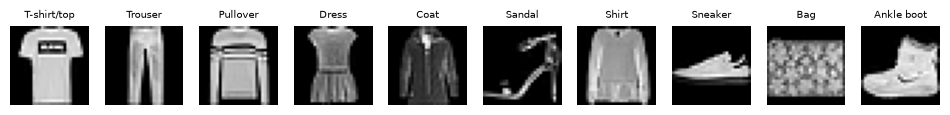

In [16]:
to_tensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])   # uint8 [0, 255] → float [0, 1]
fashion_train_full = datasets.FashionMNIST(DATA_DIR, train=True, download=True, transform=to_tensor)
fashion_test = datasets.FashionMNIST(DATA_DIR, train=False, download=True, transform=to_tensor)
CLASSES = fashion_train_full.classes
print(f"train {len(fashion_train_full)} | test {len(fashion_test)} | classes: {CLASSES}")
img0, label0 = fashion_train_full[0]
print("one image:", img0.shape, img0.dtype, f"range [{img0.min():.1f}, {img0.max():.1f}] | label {label0} = {CLASSES[label0]}")

fig, axes = plt.subplots(1, 10, figsize=(12, 1.8))
for c, ax in enumerate(axes):
    idx = int((fashion_train_full.targets == c).nonzero()[0])
    ax.imshow(fashion_train_full[idx][0].squeeze(0), cmap="gray")
    ax.set_title(CLASSES[c], fontsize=7)
    ax.axis("off")
plt.show()

In [17]:
# Measure instead of guessing: one full pass over 60,000 images with 0 vs 2 worker processes.
# (torchvision's dataset class is importable, so spawned workers can load it even from a notebook.)
for workers in [0, 2]:
    loader = DataLoader(fashion_train_full, batch_size=256, shuffle=True, num_workers=workers)
    start = time.perf_counter()
    n_seen = sum(len(yb) for _, yb in loader)
    print(f"num_workers={workers}: {n_seen} images in {time.perf_counter() - start:.2f} s")
print("For tiny images with a light transform, process start-up and inter-process copies can outweigh the parallelism;"
      " workers pay off with heavy decoding/augmentation (e.g. JPEGs).")

num_workers=0: 60000 images in 2.41 s


num_workers=2: 60000 images in 3.18 s
For tiny images with a light transform, process start-up and inter-process copies can outweigh the parallelism; workers pay off with heavy decoding/augmentation (e.g. JPEGs).


### ✍️ Your Turn

Wrap `X_toy` and `y_toy` in a `TensorDataset`, build a `DataLoader` with `batch_size=4` and **no** shuffling, and store the **number of batches** in `n_batches` (the last, smaller batch is kept).

In [18]:
X_toy, y_toy = torch.randn(10, 3), torch.arange(10)
n_batches = None  # TODO
check("n_batches", n_batches, 3, hint="len(DataLoader(TensorDataset(X_toy, y_toy), batch_size=4))")

⏳ n_batches: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
X_toy, y_toy = torch.randn(10, 3), torch.arange(10)
toy_loader = DataLoader(TensorDataset(X_toy, y_toy), batch_size=4, shuffle=False)
n_batches = len(toy_loader)                       # batches of 4, 4, 2
check("n_batches", n_batches, 3)
```

With `drop_last=True` it would be 2.
</details>

> 💡 **Interview angle:** "Your GPU sits at 30% utilization — why?" — the input pipeline is the bottleneck. Profile data loading separately, then raise `num_workers`, enable `pin_memory` (CUDA), use `persistent_workers=True`, move decoding/augmentation off the main process or onto the GPU, and pre-process data once.

## 7. The Correct Training Loop 🟡

Every PyTorch training step is the same five moves — **in this order**:

```
model.train()                       # dropout/BatchNorm in training mode
for xb, yb in train_loader:
    xb, yb = xb.to(device), yb.to(device)
    logits = model(xb)              # 1. forward (ONE pass — reuse it for metrics)
    loss = loss_fn(logits, yb)      # 2. loss
    optimizer.zero_grad()           # 3. clear old gradients
    loss.backward()                 # 4. backward
    clip_grad_norm_(...)            #    (optional) tame exploding gradients
    optimizer.step()                # 5. update   (then scheduler.step() for per-step schedules)

model.eval()                        # dropout off, BatchNorm uses running stats
with torch.inference_mode():        # no graph → less memory, faster
    ...evaluate on validation data...
```

Two efficiency details: accumulate metrics as **detached tensors** and call `.item()` once per epoch (every `.item()` forces the CPU to wait for the GPU), and never keep `loss` itself in a running sum (that keeps every step's graph alive).

In [19]:
def train_one_epoch(model, loader, loss_fn, optimizer, device, scheduler=None, max_grad_norm=None):
    model.train()
    total_loss = torch.zeros((), device=device)
    correct = torch.zeros((), device=device)
    seen = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)                                   # one forward pass…
        loss = loss_fn(logits, yb)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        if max_grad_norm is not None:
            nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()
        if scheduler is not None:
            scheduler.step()                                 # per-step schedule, AFTER optimizer.step()
        total_loss += loss.detach() * len(yb)                # …reused for the metrics (no second pass)
        correct += (logits.argmax(dim=1) == yb).sum()
        seen += len(yb)
    return total_loss.item() / seen, correct.item() / seen


@torch.inference_mode()
def evaluate(model, loader, loss_fn, device):
    model.eval()
    total_loss = torch.zeros((), device=device)
    correct = torch.zeros((), device=device)
    seen = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        total_loss += loss_fn(logits, yb) * len(yb)
        correct += (logits.argmax(dim=1) == yb).sum()
        seen += len(yb)
    return total_loss.item() / seen, correct.item() / seen


seed_everything(SEED)
cancer_model = nn.Sequential(nn.Linear(30, 32), nn.ReLU(), nn.Dropout(0.2), nn.Linear(32, 2)).to(DEVICE)
optimizer = torch.optim.AdamW(param_groups(cancer_model, 1e-2), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

print(f"before training: val loss {evaluate(cancer_model, cancer_val_loader, loss_fn, DEVICE)[0]:.3f} (≈ ln 2 = {math.log(2):.3f} expected)")
for epoch in range(1, 31):
    train_loss, train_acc = train_one_epoch(cancer_model, cancer_train_loader, loss_fn, optimizer, DEVICE, max_grad_norm=1.0)
    val_loss, val_acc = evaluate(cancer_model, cancer_val_loader, loss_fn, DEVICE)
    if epoch % 10 == 0 or epoch == 1:
        print(f"epoch {epoch:2d} | train loss {train_loss:.3f} acc {train_acc:.3f} | val loss {val_loss:.3f} acc {val_acc:.3f}")

before training: val loss 0.700 (≈ ln 2 = 0.693 expected)
epoch  1 | train loss 0.643 acc 0.704 | val loss 0.575 acc 0.772


epoch 10 | train loss 0.140 acc 0.968 | val loss 0.150 acc 0.956


epoch 20 | train loss 0.076 acc 0.985 | val loss 0.090 acc 0.974


epoch 30 | train loss 0.055 acc 0.988 | val loss 0.074 acc 0.974


Note that *train* accuracy is a running average measured **during** the epoch (with dropout on and weights changing), so it can even be lower than validation accuracy — that's expected, not a bug.

### ✍️ Your Turn

Given a batch of `logits` (shape `(4, 3)`) and `labels`, compute the **accuracy** as a Python float using `argmax` over the class dimension.

In [20]:
batch_logits = torch.tensor([[2.0, 0.1, -1.0],
                             [0.2, 0.3, 0.1],
                             [-1.0, 0.0, 3.0],
                             [0.5, 0.4, 0.3]])
batch_labels = torch.tensor([0, 1, 2, 2])
batch_acc = None  # TODO
check("batch_accuracy", batch_acc, 0.75, hint="(batch_logits.argmax(dim=1) == batch_labels).float().mean().item()")

⏳ batch_accuracy: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
batch_logits = torch.tensor([[2.0, 0.1, -1.0], [0.2, 0.3, 0.1], [-1.0, 0.0, 3.0], [0.5, 0.4, 0.3]])
batch_labels = torch.tensor([0, 1, 2, 2])
batch_acc = (batch_logits.argmax(dim=1) == batch_labels).float().mean().item()
check("batch_accuracy", batch_acc, 0.75)
```

No softmax needed: softmax never changes which logit is largest.
</details>

> 💡 **Interview angle:** "Write a training loop" — narrate the order (forward → loss → `zero_grad` → `backward` → `step`), then *volunteer* the details that signal experience: `model.train()`/`model.eval()`, `inference_mode` for validation, metrics from the same forward pass, gradient clipping, and scheduler stepping after the optimizer.

## 8. Device-Agnostic Code (CUDA → MPS → CPU) 🟢

Write code once and let it run anywhere: pick `DEVICE` at the top (done in Setup), then move **both** the model (`model.to(DEVICE)`) and every batch (`xb.to(DEVICE)`) there. Tensors on different devices can't be combined. GPU calls are **asynchronous** — synchronize before timing.

In [21]:
cpu_input = torch.randn(4, 30)
try:
    cancer_model(cpu_input)                              # model is on DEVICE, input is on CPU
    print(f"no error: DEVICE is {DEVICE}, so model and input are both on the CPU")
except RuntimeError as err:
    print("device mismatch →", str(err)[:110])
print("fixed:", cancer_model(cpu_input.to(DEVICE)).shape)

size = 2048
a_cpu, b_cpu = torch.randn(size, size), torch.randn(size, size)
start = time.perf_counter()
for _ in range(5):
    a_cpu @ b_cpu
cpu_s = (time.perf_counter() - start) / 5
if DEVICE.type != "cpu":
    a_gpu, b_gpu = a_cpu.to(DEVICE), b_cpu.to(DEVICE)
    a_gpu @ b_gpu
    sync(DEVICE)                                         # warm-up: first call includes kernel setup
    start = time.perf_counter()
    for _ in range(5):
        a_gpu @ b_gpu
    sync(DEVICE)
    gpu_s = (time.perf_counter() - start) / 5
    print(f"{size}×{size} matmul: CPU {cpu_s * 1000:.0f} ms | {DEVICE} {gpu_s * 1000:.0f} ms → {cpu_s / gpu_s:.1f}× faster on {DEVICE}")
else:
    print(f"{size}×{size} matmul on CPU: {cpu_s * 1000:.0f} ms (⏭️ no GPU found — run on Colab with a GPU to compare)")

device mismatch → Tensor for argument input is on cpu but expected on mps
fixed: torch.Size([4, 2])


2048×2048 matmul: CPU 24 ms | mps 3 ms → 7.3× faster on mps


### ✍️ Your Turn

Move `v_np` (a NumPy array) to `DEVICE` as a float32 tensor, square it on the device, and bring the result back as a **NumPy array** in `squared_np`.

In [22]:
v_np = np.array([1.0, -2.0, 3.0])
squared_np = None  # TODO
check("device_roundtrip", squared_np, [1.0, 4.0, 9.0], hint="torch.tensor(v_np, dtype=torch.float32, device=DEVICE) ** 2, then .cpu().numpy()")
if squared_np is not None:
    assert isinstance(squared_np, np.ndarray), "❌ return a NumPy array"

⏳ device_roundtrip: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
v_np = np.array([1.0, -2.0, 3.0])
squared_np = (torch.tensor(v_np, dtype=torch.float32, device=DEVICE) ** 2).cpu().numpy()
check("device_roundtrip", squared_np, [1.0, 4.0, 9.0])
assert isinstance(squared_np, np.ndarray)
```

`dtype=torch.float32` matters on MPS, which rejects float64.
</details>

> 💡 **Interview angle:** "How do you make code run on CPU, CUDA, and Apple Silicon?" — select the device once (`cuda` → `mps` → `cpu`), move model and data with `.to(device)`, keep device-specific features (pinned memory, `GradScaler`, `cudnn.benchmark`) behind `if device.type == "cuda"`, and call `synchronize()` before timing GPU code.

## 9. CNN Basics on Real Images 🟡

A fully connected layer treats a 28×28 image as 784 unrelated numbers. A **convolutional layer** (`nn.Conv2d`) slides small learnable filters (e.g. 3×3) across the image, so it:

- reuses the same few weights at every position (**weight sharing** → far fewer parameters),
- detects a pattern (edge, texture) wherever it appears (**translation equivariance**),
- keeps the 2-D layout, so later layers combine nearby features into bigger ones.

**Output size** along each spatial dimension: $\left\lfloor \frac{H + 2p - k}{s} \right\rfloor + 1$ (k = kernel, s = stride, p = padding). **Parameters**: $C_{out}\cdot C_{in}\cdot k\cdot k + C_{out}$. **Max pooling** (`nn.MaxPool2d(2)`) keeps the largest value in each 2×2 window, halving height and width.

First, intuition: a hand-made 3×3 **edge filter** applied to a real image with `F.conv2d` — a CNN *learns* filters like this.

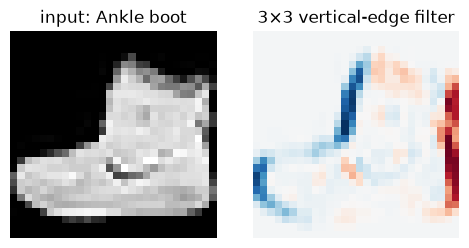

In [23]:
sobel_x = torch.tensor([[-1.0, 0.0, 1.0],
                        [-2.0, 0.0, 2.0],
                        [-1.0, 0.0, 1.0]]).view(1, 1, 3, 3)       # (out_channels, in_channels, k, k)
sample_img = fashion_train_full[0][0].unsqueeze(0)               # (1, 1, 28, 28)
edges = F.conv2d(sample_img, sobel_x, padding=1)

fig, axes = plt.subplots(1, 2, figsize=(5, 2.5))
axes[0].imshow(sample_img[0, 0], cmap="gray")
axes[0].set_title(f"input: {CLASSES[fashion_train_full[0][1]]}")
axes[1].imshow(edges[0, 0], cmap="RdBu")
axes[1].set_title("3×3 vertical-edge filter")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

In [24]:
small_cnn = nn.Sequential(
    nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 28 → 14
    nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 14 → 7
    nn.Flatten(), nn.Linear(32 * 7 * 7, 10),
)
out = torch.zeros(8, 1, 28, 28)
print(f"{'input':32s} {tuple(out.shape)}")
for layer in small_cnn:                                           # trace shapes layer by layer
    out = layer(out)
    print(f"{str(layer)[:32]:32s} {tuple(out.shape)}")

mlp_baseline = nn.Sequential(nn.Flatten(), nn.Linear(784, 128), nn.ReLU(), nn.Linear(128, 10))
count = lambda m: sum(p.numel() for p in m.parameters())
print(f"\nparameters → small CNN: {count(small_cnn):,} | MLP with one 128-unit hidden layer: {count(mlp_baseline):,}")

input                            (8, 1, 28, 28)
Conv2d(1, 16, kernel_size=(3, 3) (8, 16, 28, 28)
ReLU()                           (8, 16, 28, 28)
MaxPool2d(kernel_size=2, stride= (8, 16, 14, 14)
Conv2d(16, 32, kernel_size=(3, 3 (8, 32, 14, 14)
ReLU()                           (8, 32, 14, 14)
MaxPool2d(kernel_size=2, stride= (8, 32, 7, 7)
Flatten(start_dim=1, end_dim=-1) (8, 1568)
Linear(in_features=1568, out_fea (8, 10)

parameters → small CNN: 20,490 | MLP with one 128-unit hidden layer: 101,770


**Same budget, CNN vs MLP.** Train both for 2 epochs on 10,000 training images and compare on 5,000 *other* training images held out for validation (the official test set stays untouched until the project).

In [25]:
perm_demo = torch.randperm(len(fashion_train_full), generator=torch.Generator().manual_seed(0))
demo_train = DataLoader(Subset(fashion_train_full, perm_demo[:10_000].tolist()), batch_size=128, shuffle=True,
                        generator=torch.Generator().manual_seed(0))
demo_val = DataLoader(Subset(fashion_train_full, perm_demo[10_000:15_000].tolist()), batch_size=512)

demo_results = {}
for name, model in [("MLP", mlp_baseline), ("CNN", small_cnn)]:
    seed_everything(SEED)
    model.to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=1e-3)
    start = time.perf_counter()
    for epoch in range(2):
        train_one_epoch(model, demo_train, nn.CrossEntropyLoss(), opt, DEVICE)
    val_loss, val_acc = evaluate(model, demo_val, nn.CrossEntropyLoss(), DEVICE)
    demo_results[name] = val_acc
    print(f"{name}: {count(model):7,} params | val acc {val_acc:.3f} | val loss {val_loss:.3f} | {time.perf_counter() - start:.1f} s")

diff = demo_results["CNN"] - demo_results["MLP"]
print(f"\nThe CNN has {count(mlp_baseline) / count(small_cnn):.1f}× fewer parameters and is {abs(diff) * 100:.1f} points "
      f"{'more' if diff > 0 else 'less'} accurate after this tiny 2-epoch budget. "
      "Short runs favour the MLP (it converges fast); with more epochs, BatchNorm, and augmentation the CNN pulls clearly ahead — the mini project shows it.")

MLP: 101,770 params | val acc 0.803 | val loss 0.577 | 1.4 s


CNN:  20,490 params | val acc 0.789 | val loss 0.561 | 1.6 s

The CNN has 5.0× fewer parameters and is 1.4 points less accurate after this tiny 2-epoch budget. Short runs favour the MLP (it converges fast); with more epochs, BatchNorm, and augmentation the CNN pulls clearly ahead — the mini project shows it.


### ✍️ Your Turn

What is the output shape of `nn.Conv2d(1, 8, kernel_size=5)` (stride 1, no padding) applied to a batch of shape `(4, 1, 28, 28)`? Store it as a tuple in `conv_shape` — work it out with the formula first, then confirm with code.

In [26]:
conv_shape = None  # TODO
check("conv_shape", conv_shape, (4, 8, 24, 24), hint="(28 + 2·0 − 5) / 1 + 1 = 24; the channel dimension becomes out_channels.")

⏳ conv_shape: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
conv_shape = tuple(nn.Conv2d(1, 8, kernel_size=5)(torch.zeros(4, 1, 28, 28)).shape)
check("conv_shape", conv_shape, (4, 8, 24, 24))
```
</details>

> 💡 **Interview angle:** "Why CNNs for images instead of MLPs?" — weight sharing and local connectivity give far fewer parameters, built-in translation equivariance, and a hierarchy of features (edges → parts → objects). Be ready to compute an output shape and a parameter count on the whiteboard.

## 10. Regularization: Dropout, BatchNorm, Weight Decay, Augmentation 🟡

| Tool | Train mode | Eval mode |
|---|---|---|
| `nn.Dropout(p)` | zero each unit with prob. `p`, scale survivors by `1/(1-p)` (inverted dropout) | identity — no dropping, **no scaling** |
| `nn.BatchNorm2d` | normalize with the **batch** mean/var and update the running averages | normalize with the stored **running** mean/var; buffers unchanged |
| Weight decay (AdamW) | shrink weights every step | — |
| Data augmentation | random flips/crops/rotations of **training** images | none — val/test use a deterministic transform |

That table is why `model.train()` and `model.eval()` exist.

In [27]:
drop = nn.Dropout(p=0.5)
ones = torch.ones(8)
drop.train()
print("Dropout train:", drop(ones).tolist())
drop.eval()
print("Dropout eval :", drop(ones).tolist())

bn = nn.BatchNorm1d(3)
data_bn = torch.randn(64, 3) * 5 + 10
print("\nBatchNorm running_mean at init    :", bn.running_mean.tolist())
bn.train()
bn(data_bn)
print("after 1 batch in train mode       :", [round(v, 3) for v in bn.running_mean.tolist()])
bn.eval()
bn(data_bn)
print("after 1 batch in eval mode (same) :", [round(v, 3) for v in bn.running_mean.tolist()])
print("buffers (saved in state_dict, not trained):", [name for name, _ in bn.named_buffers()])

Dropout train: [2.0, 2.0, 2.0, 0.0, 2.0, 0.0, 0.0, 2.0]
Dropout eval : [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]

BatchNorm running_mean at init    : [0.0, 0.0, 0.0]
after 1 batch in train mode       : [0.987, 1.016, 1.111]
after 1 batch in eval mode (same) : [0.987, 1.016, 1.111]
buffers (saved in state_dict, not trained): ['running_mean', 'running_var', 'num_batches_tracked']


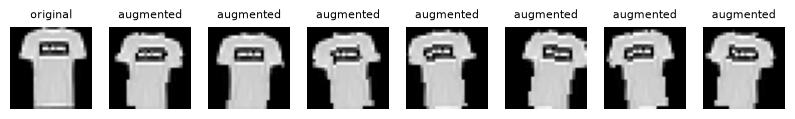

In [28]:
augment = T.Compose([
    T.ToImage(),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomCrop(28, padding=2),              # shift the image by up to 2 pixels
    T.RandomRotation(degrees=10),
    T.ToDtype(torch.float32, scale=True),
])
raw_pil, raw_label = datasets.FashionMNIST(DATA_DIR, train=True)[1]    # PIL image, no transform
fig, axes = plt.subplots(1, 8, figsize=(10, 1.6))
axes[0].imshow(to_tensor(raw_pil)[0], cmap="gray")
axes[0].set_title("original", fontsize=8)
for ax in axes[1:]:
    ax.imshow(augment(raw_pil)[0], cmap="gray")
    ax.set_title("augmented", fontsize=8)
for ax in axes:
    ax.axis("off")
plt.show()

Augmentation must keep the label true: flipping a T-shirt left-right is still a T-shirt, but flipping a digit "6" upside down makes it a "9". Choose transforms that match your data.

### ✍️ Your Turn

Compute the **mean** and **standard deviation** of all FashionMNIST training pixels scaled to `[0, 1]`, using the raw `uint8` tensor `fashion_train_full.data`. Store Python floats in `pixel_mean` and `pixel_std` (these are the numbers you'd pass to `T.Normalize`).

In [29]:
pixel_mean, pixel_std = None, None  # TODO
check("pixel_mean", pixel_mean, 0.2860406, rtol=1e-4, hint="fashion_train_full.data.float() / 255, then .mean().item()")
check("pixel_std", pixel_std, 0.3530242, rtol=1e-4, hint="… and .std().item()")

⏳ pixel_mean: not attempted yet — replace None with your answer.
⏳ pixel_std: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
pixels = fashion_train_full.data.float() / 255
pixel_mean, pixel_std = pixels.mean().item(), pixels.std().item()
check("pixel_mean", pixel_mean, 0.2860406, rtol=1e-4)
check("pixel_std", pixel_std, 0.3530242, rtol=1e-4)
```

In a real pipeline compute these on the **training split only** (the project does) and reuse them for validation and test.
</details>

> 💡 **Interview angle:** "What changes between `train()` and `eval()`?" — dropout turns off (inverted dropout already scaled during training) and BatchNorm switches from batch statistics to running statistics and stops updating them. Forgetting `eval()` gives noisy, lower validation scores *and* silently corrupts BatchNorm's running averages.

## 11. Learning-Rate Schedules: Warmup + Cosine 🟡

The learning rate doesn't have to be constant:

- **Warmup** — start tiny and ramp up linearly over the first steps. At initialization gradients can be large and Adam's second-moment estimates are still noisy, so big early steps can destabilize training. Standard for transformers and large batches.
- **Cosine decay** — then glide smoothly down to (near) zero, so the final steps make small, careful refinements.

$$\text{lr}(t) = \begin{cases} \text{base} \cdot \frac{t+1}{W} & t < W \\ \text{base} \cdot \frac{1}{2}\left(1 + \cos\left(\pi \frac{t - W}{T - W}\right)\right) & t \ge W \end{cases}$$

Most schedules in modern training step **once per batch**, right **after** `optimizer.step()`.

LambdaLR and SequentialLR(LinearLR → CosineAnnealingLR) agree: True
lr at step 0: 1.0e-05 | step 99: 1.0e-03 | step 550: 5.0e-04 | last: 3.0e-09


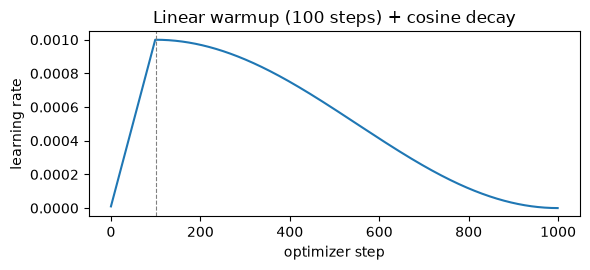

In [30]:
def warmup_cosine_factor(step, warmup_steps, total_steps):
    if step < warmup_steps:
        return (step + 1) / warmup_steps
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * (1 + math.cos(math.pi * progress))


BASE_LR, WARMUP, TOTAL = 1e-3, 100, 1000
dummy = nn.Parameter(torch.zeros(1))

opt_a = torch.optim.AdamW([dummy], lr=BASE_LR)
sched_a = torch.optim.lr_scheduler.LambdaLR(opt_a, lambda s: warmup_cosine_factor(s, WARMUP, TOTAL))

opt_b = torch.optim.AdamW([dummy], lr=BASE_LR)
sched_b = torch.optim.lr_scheduler.SequentialLR(opt_b, schedulers=[
    torch.optim.lr_scheduler.LinearLR(opt_b, start_factor=1 / WARMUP, end_factor=1.0, total_iters=WARMUP - 1),
    torch.optim.lr_scheduler.CosineAnnealingLR(opt_b, T_max=TOTAL - WARMUP),
], milestones=[WARMUP])

lrs_a, lrs_b = [], []
for step in range(TOTAL):
    lrs_a.append(opt_a.param_groups[0]["lr"])
    lrs_b.append(opt_b.param_groups[0]["lr"])
    opt_a.step()
    sched_a.step()
    opt_b.step()
    sched_b.step()
print("LambdaLR and SequentialLR(LinearLR → CosineAnnealingLR) agree:", np.allclose(lrs_a, lrs_b, atol=1e-8))
print(f"lr at step 0: {lrs_a[0]:.1e} | step {WARMUP - 1}: {lrs_a[WARMUP - 1]:.1e} | step 550: {lrs_a[550]:.1e} | last: {lrs_a[-1]:.1e}")

fig, ax = plt.subplots(figsize=(6, 2.8))
ax.plot(lrs_a)
ax.axvline(WARMUP, color="gray", ls="--", lw=0.8)
ax.set(title="Linear warmup (100 steps) + cosine decay", xlabel="optimizer step", ylabel="learning rate")
plt.tight_layout()
plt.show()

In [31]:
# Calling the scheduler before the optimizer skips the first value of the schedule — PyTorch warns about it
opt_wrong = torch.optim.SGD([nn.Parameter(torch.zeros(1))], lr=0.1)
sched_wrong = torch.optim.lr_scheduler.StepLR(opt_wrong, step_size=1, gamma=0.5)
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    sched_wrong.step()                        # ❌ before optimizer.step()
    opt_wrong.step()
messages = [str(w.message) for w in caught]
print("warning captured:" if messages else "no warning was raised in this version", messages[0][:95] + "…" if messages else "")

warning captured: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, y…


### ✍️ Your Turn

An `AdamW` optimizer has base `lr = 1e-3` and is wrapped in `LinearLR(opt, start_factor=0.1, total_iters=10)`. Create them and store the learning rate **before any step** (read it from `opt.param_groups[0]["lr"]`) in `first_lr`.

In [32]:
first_lr = None  # TODO
check("first_lr", first_lr, 1e-4, rtol=1e-6, hint="Creating the scheduler immediately sets lr = base_lr · start_factor.")

⏳ first_lr: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
opt_ty = torch.optim.AdamW([nn.Parameter(torch.zeros(1))], lr=1e-3)
sched_ty = torch.optim.lr_scheduler.LinearLR(opt_ty, start_factor=0.1, total_iters=10)
first_lr = opt_ty.param_groups[0]["lr"]
check("first_lr", first_lr, 1e-4, rtol=1e-6)
```
</details>

> 💡 **Interview angle:** "Why warmup?" — early gradients are large and Adam's variance estimates are unreliable, so a full learning rate at step 0 can blow up training (especially transformers and large batches). "Why cosine?" — a smooth decay that spends many steps at moderate learning rates and ends with small refinements, with one fewer knob than step decay.

## 12. Mixed Precision and `torch.compile` 🔴

**Mixed precision** runs most matrix multiplies and convolutions in a 16-bit float while keeping the weights and numerically sensitive ops (softmax, losses) in float32. You wrap the forward pass in `torch.autocast(device_type, dtype)`.

| 16-bit type | Range | Needs `GradScaler`? | Where |
|---|---|---|---|
| `float16` | max 65,504 — small gradients can **underflow** to 0 | yes: scale the loss up, unscale before the step | older NVIDIA GPUs, MPS |
| `bfloat16` | same range as float32, less precision | no | modern NVIDIA (Ampere+), TPUs, CPUs |

The benefits — less activation memory and faster math — come from hardware with fast 16-bit kernels (NVIDIA tensor cores). **Always measure** on your hardware.

In [33]:
if DEVICE.type == "cuda":
    AMP_DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
elif DEVICE.type == "mps":
    AMP_DTYPE = torch.float16
else:
    AMP_DTYPE = torch.bfloat16
print(f"device {DEVICE} → autocast dtype {AMP_DTYPE}")

probe = nn.Sequential(nn.Linear(16, 16), nn.ReLU(), nn.Linear(16, 4)).to(DEVICE)
with torch.autocast(device_type=DEVICE.type, dtype=AMP_DTYPE):
    probe_logits = probe(torch.randn(8, 16, device=DEVICE))
    probe_loss = F.cross_entropy(probe_logits, torch.zeros(8, dtype=torch.long, device=DEVICE))
print(f"inside autocast → linear output {probe_logits.dtype}, cross-entropy {probe_loss.dtype}, weights stay {probe[0].weight.dtype}")
print("float16 largest value:", torch.finfo(torch.float16).max, "| bfloat16:", f"{torch.finfo(torch.bfloat16).max:.2e}")

device mps → autocast dtype torch.float16


inside autocast → linear output torch.float16, cross-entropy torch.float32, weights stay torch.float32
float16 largest value: 65504.0 | bfloat16: 3.39e+38


In [34]:
def time_training_steps(model, xb, yb, use_amp, steps=30):
    opt = torch.optim.AdamW(model.parameters(), lr=1e-3)
    use_scaler = use_amp and AMP_DTYPE == torch.float16 and DEVICE.type in ("cuda", "mps")
    scaler = torch.amp.GradScaler(DEVICE.type, enabled=use_scaler) if DEVICE.type in ("cuda", "mps") else None
    model.train()
    for step in range(steps + 3):
        if step == 3:                                     # skip warm-up steps
            sync(DEVICE)
            start = time.perf_counter()
        with torch.autocast(device_type=DEVICE.type, dtype=AMP_DTYPE, enabled=use_amp):
            loss = F.cross_entropy(model(xb), yb)
        opt.zero_grad(set_to_none=True)
        if scaler is not None:
            scaler.scale(loss).backward()                 # scale up so float16 gradients don't underflow
            scaler.step(opt)                              # unscales; skips the step if grads are inf/nan
            scaler.update()
        else:
            loss.backward()
            opt.step()
    sync(DEVICE)
    return (time.perf_counter() - start) / steps, loss.item()


amp_x = torch.stack([fashion_train_full[i][0] for i in range(256)]).to(DEVICE)
amp_y = torch.tensor([fashion_train_full[i][1] for i in range(256)], device=DEVICE)
seed_everything(SEED)
base_cnn = nn.Sequential(nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
                         nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
                         nn.Flatten(), nn.Linear(64 * 7 * 7, 10))
results_amp = {}
for use_amp in [False, True]:
    model = copy.deepcopy(base_cnn).to(DEVICE)
    results_amp[use_amp] = time_training_steps(model, amp_x, amp_y, use_amp)
    print(f"autocast={str(use_amp):5s}: {results_amp[use_amp][0] * 1000:6.1f} ms/step | loss after 30 steps {results_amp[use_amp][1]:.3f}")
speedup = results_amp[False][0] / results_amp[True][0]
print(f"→ mixed precision was {speedup:.2f}× the speed of float32 on {DEVICE} for this small CNN"
      + (" — a real win here." if speedup > 1.1 else " — no win for a model this small on this hardware; the gains show up on large models with fast 16-bit kernels (e.g. NVIDIA GPUs)."))

autocast=False:    4.8 ms/step | loss after 30 steps 0.417


autocast=True :    5.5 ms/step | loss after 30 steps 0.415
→ mixed precision was 0.87× the speed of float32 on mps for this small CNN — no win for a model this small on this hardware; the gains show up on large models with fast 16-bit kernels (e.g. NVIDIA GPUs).


**`torch.compile`** traces your model's Python code into a graph (TorchDynamo) and generates fused, optimized kernels (TorchInductor). The first call is slow (compilation); later calls with the same input shapes are faster. It can fail on unusual code or unsupported platforms, so the cell below reports honestly either way.

In [35]:
eval_model = copy.deepcopy(base_cnn).to(DEVICE).eval()
bench_x = amp_x[:64]


def time_forward(fn, repeats=20):
    with torch.inference_mode():
        fn(bench_x)
        sync(DEVICE)
        start = time.perf_counter()
        for _ in range(repeats):
            fn(bench_x)
        sync(DEVICE)
    return (time.perf_counter() - start) / repeats


try:
    compiled_model = torch.compile(eval_model)
    start = time.perf_counter()
    with torch.inference_mode():
        compiled_out = compiled_model(bench_x)
    sync(DEVICE)
    compile_s = time.perf_counter() - start
    with torch.inference_mode():
        same = torch.allclose(compiled_out, eval_model(bench_x), atol=1e-4)
    eager_ms, compiled_ms = time_forward(eval_model) * 1000, time_forward(compiled_model) * 1000
    print(f"torch.compile on {DEVICE}: first call {compile_s:.1f} s (compilation) | outputs match eager: {same}")
    print(f"forward pass: eager {eager_ms:.2f} ms vs compiled {compiled_ms:.2f} ms → {eager_ms / compiled_ms:.2f}×")
except Exception as err:                                  # noqa: BLE001 — report any backend failure honestly
    print(f"⏭️ torch.compile is not usable here ({type(err).__name__}: {str(err)[:120]}). "
          "Try it on Linux with a CUDA GPU (e.g. Google Colab).")

torch.compile on mps: first call 0.7 s (compilation) | outputs match eager: True
forward pass: eager 0.82 ms vs compiled 0.29 ms → 2.84×


### ✍️ Your Turn

A float16 activation holds the value `70000.0`. Look up the **largest finite float16 value** with `torch.finfo` and store it in `fp16_max` — then predict what `torch.tensor(70000.0).half()` becomes.

In [36]:
fp16_max = None  # TODO
check("fp16_max", fp16_max, 65504.0, hint="torch.finfo(torch.float16).max")

⏳ fp16_max: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
fp16_max = torch.finfo(torch.float16).max
check("fp16_max", fp16_max, 65504.0)
print(torch.tensor(70000.0).half())     # tensor(inf, dtype=torch.float16) — overflow
```

Overflow to `inf` (and underflow of tiny gradients to 0) is why float16 training needs a `GradScaler`, while bfloat16 — with float32's range — does not.
</details>

> 💡 **Interview angle:** "float16 vs bfloat16?" — same 16 bits, split differently: float16 has more precision but a tiny range (overflow/underflow → needs loss scaling); bfloat16 keeps float32's exponent range (no scaler) with coarser precision. Mention that autocast keeps weights in float32 and runs losses/softmax in float32.

## 13. Saving, Loading, Checkpoints, and Reproducibility 🟢

- Save the **`state_dict`** (a dictionary of tensors), not the whole pickled model object — it survives code refactors.
- Load with `torch.load(path, map_location=DEVICE, weights_only=True)`. Since PyTorch 2.6 `weights_only=True` is the default: it refuses to unpickle arbitrary Python objects, which protects you from malicious checkpoint files.
- To **resume training**, a checkpoint also needs the optimizer state (Adam's moment buffers), the scheduler, the epoch, and ideally the random-number-generator states.

In [37]:
ckpt_model = nn.Sequential(nn.Linear(30, 32), nn.ReLU(), nn.Linear(32, 2)).to(DEVICE)
weights_path = OUTPUT_DIR / "cancer_mlp_weights.pt"
torch.save(ckpt_model.state_dict(), weights_path)

fresh = nn.Sequential(nn.Linear(30, 32), nn.ReLU(), nn.Linear(32, 2)).to(DEVICE)
fresh.load_state_dict(torch.load(weights_path, map_location=DEVICE, weights_only=True))
probe_x = cancer_val.X[:5].to(DEVICE)
with torch.inference_mode():
    print("reloaded model gives identical outputs:", torch.equal(ckpt_model(probe_x), fresh(probe_x)),
          f"| file size {weights_path.stat().st_size / 1024:.1f} KB")

reloaded model gives identical outputs: True | file size 6.6 KB


**Does resuming really continue the same run?** Train 4 epochs in one go, versus 2 epochs → save a full checkpoint → build everything fresh → load → 2 more epochs. On the CPU with the shuffle generator's state saved, the final weights should be *bit-for-bit identical*.

In [38]:
def make_run(seed=0):
    torch.manual_seed(seed)
    model = nn.Sequential(nn.Linear(30, 32), nn.ReLU(), nn.Linear(32, 2))
    opt = torch.optim.AdamW(model.parameters(), lr=1e-3)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=4 * len(cancer_train_loader))
    gen = torch.Generator().manual_seed(seed)
    loader = DataLoader(cancer_train, batch_size=32, shuffle=True, generator=gen)
    return model, opt, sched, gen, loader


cpu = torch.device("cpu")
model_a, opt_a, sched_a, gen_a, loader_a = make_run()
for epoch in range(4):
    train_one_epoch(model_a, loader_a, loss_fn, opt_a, cpu, scheduler=sched_a)

model_b, opt_b, sched_b, gen_b, loader_b = make_run()
for epoch in range(2):
    train_one_epoch(model_b, loader_b, loss_fn, opt_b, cpu, scheduler=sched_b)
checkpoint_path = OUTPUT_DIR / "resume_checkpoint.pt"
torch.save({"epoch": 2, "model": model_b.state_dict(), "optimizer": opt_b.state_dict(),
            "scheduler": sched_b.state_dict(), "loader_generator": gen_b.get_state()}, checkpoint_path)

model_c, opt_c, sched_c, gen_c, loader_c = make_run(seed=123)          # different seed on purpose: everything must come from the file
ckpt = torch.load(checkpoint_path, map_location=cpu, weights_only=True)
model_c.load_state_dict(ckpt["model"])
opt_c.load_state_dict(ckpt["optimizer"])
sched_c.load_state_dict(ckpt["scheduler"])
gen_c.set_state(ckpt["loader_generator"])
for epoch in range(ckpt["epoch"], 4):
    train_one_epoch(model_c, loader_c, loss_fn, opt_c, cpu, scheduler=sched_c)

identical = all(torch.equal(p, q) for p, q in zip(model_a.parameters(), model_c.parameters()))
print("checkpoint keys:", list(ckpt.keys()))
print("resumed run is bit-for-bit identical to the uninterrupted run:", identical)

checkpoint keys: ['epoch', 'model', 'optimizer', 'scheduler', 'loader_generator']
resumed run is bit-for-bit identical to the uninterrupted run: True


**Reproducibility checklist:** seed Python, NumPy and PyTorch (`seed_everything`); pass a seeded `generator` to `DataLoader` (and a `worker_init_fn` if workers use NumPy randomness); on CUDA optionally `torch.use_deterministic_algorithms(True)` (some ops then need `CUBLAS_WORKSPACE_CONFIG=:4096:8`) and `torch.backends.cudnn.benchmark = False`. GPU kernels are not always deterministic, so expect tiny run-to-run differences on GPUs even with seeds — compare runs with a tolerance and several seeds.

In [39]:
def short_run(seed):
    seed_everything(seed)
    model = nn.Sequential(nn.Linear(30, 32), nn.ReLU(), nn.Dropout(0.2), nn.Linear(32, 2))
    opt = torch.optim.AdamW(model.parameters(), lr=1e-3)
    loader = DataLoader(cancer_train, batch_size=32, shuffle=True, generator=torch.Generator().manual_seed(seed))
    return [train_one_epoch(model, loader, loss_fn, opt, cpu)[0] for _ in range(3)]


print("seed 0, run 1:", [round(v, 6) for v in short_run(0)])
print("seed 0, run 2:", [round(v, 6) for v in short_run(0)])
print("seed 1       :", [round(v, 6) for v in short_run(1)])

seed 0, run 1: [0.699939, 0.566217, 0.459541]
seed 0, run 2: [0.699939, 0.566217, 0.459541]
seed 1       : [0.598658, 0.473407, 0.383821]


### ✍️ Your Turn

Save `yt_net`'s `state_dict` to `OUTPUT_DIR / "your_turn.pt"`, load it into a **new** `nn.Linear(4, 2)` called `loaded_net`, and store `loaded_net(inp)` in `loaded_out`.

In [40]:
torch.manual_seed(7)
yt_net = nn.Linear(4, 2)
inp = torch.randn(3, 4)
loaded_out = None  # TODO
check("loaded_out", loaded_out, yt_net(inp), hint="torch.save(yt_net.state_dict(), path); loaded_net.load_state_dict(torch.load(path, weights_only=True))")

⏳ loaded_out: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
torch.manual_seed(7)
yt_net = nn.Linear(4, 2)
inp = torch.randn(3, 4)
path = OUTPUT_DIR / "your_turn.pt"
torch.save(yt_net.state_dict(), path)
loaded_net = nn.Linear(4, 2)                         # new random weights…
loaded_net.load_state_dict(torch.load(path, weights_only=True))   # …replaced by the saved ones
loaded_out = loaded_net(inp)
check("loaded_out", loaded_out, yt_net(inp))
```
</details>

> 💡 **Interview angle:** "What do you save to resume training?" — model `state_dict`, optimizer state (Adam moments!), scheduler state, epoch/step, best validation metric, and RNG/generator states. Reloading only the weights and restarting Adam from zero causes a visible loss spike.

## 14. Debugging Habits 🟡

Experienced engineers don't wait 3 hours to find out a model doesn't learn. Five habits:

1. **Check the initial loss** — for C balanced classes it should be ≈ ln C.
2. **Overfit one small batch** — a correct model + loop drives the loss near 0 within a few hundred steps. If it can't, the bug is in the code, not the data size.
3. **Assert shapes** at module boundaries.
4. **Watch gradient norms** per layer — zeros mean a broken graph or dead units; huge values mean explosions.
5. **Catch NaNs early** — `torch.isfinite(loss)` every step; `torch.autograd.detect_anomaly()` to find the operation that produced them (slow: debugging only).

In [41]:
seed_everything(SEED)
debug_cnn = nn.Sequential(nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
                          nn.Flatten(), nn.Linear(16 * 14 * 14, 10)).to(DEVICE)
one_x, one_y = amp_x[:32], amp_y[:32]

logits0 = debug_cnn(one_x)
assert logits0.shape == (32, 10), f"expected (32, 10), got {tuple(logits0.shape)}"      # habit 3
print(f"1) initial loss {F.cross_entropy(logits0, one_y).item():.3f} vs ln(10) = {math.log(10):.3f}")

opt = torch.optim.AdamW(debug_cnn.parameters(), lr=1e-3)
for step in range(200):                                                                  # habit 2
    loss = F.cross_entropy(debug_cnn(one_x), one_y)
    opt.zero_grad()
    loss.backward()
    if step == 0:                                                                        # habit 4
        norms = {name: p.grad.norm().item() for name, p in debug_cnn.named_parameters()}
    opt.step()
print(f"2) after 200 steps on ONE batch: loss {loss.item():.4f} → " + ("✅ the pipeline can learn" if loss.item() < 0.05 else "❌ something is broken"))
print("4) gradient norms at step 0:", {k: round(v, 4) for k, v in norms.items()})
total_norm = nn.utils.clip_grad_norm_(debug_cnn.parameters(), max_norm=float("inf"))    # returns the total norm
print(f"   total gradient norm (last step): {total_norm.item():.4f}")

1) initial loss 2.369 vs ln(10) = 2.303


2) after 200 steps on ONE batch: loss 0.0031 → ✅ the pipeline can learn
4) gradient norms at step 0: {'0.weight': 0.1401, '0.bias': 0.1054, '4.weight': 3.3498, '4.bias': 0.1941}
   total gradient norm (last step): 0.0116


In [42]:
x_bad = torch.tensor([-1.0, 4.0], requires_grad=True)
y_bad = torch.sqrt(x_bad)                                  # sqrt(-1) = nan
print("5) forward value:", y_bad.tolist(), "| finite?", torch.isfinite(y_bad).all().item())
with warnings.catch_warnings(record=True):                 # anomaly mode emits long warnings; keep the output short
    warnings.simplefilter("always")
    try:
        with torch.autograd.detect_anomaly():
            torch.sqrt(x_bad).sum().backward()
    except RuntimeError as err:
        print("   detect_anomaly pinpoints it →", str(err))

5) forward value: [nan, 2.0] | finite? False
   detect_anomaly pinpoints it → Function 'SqrtBackward0' returned nan values in its 0th output.


### ✍️ Your Turn

Write `has_bad_grad(model)` that returns `True` if **any** parameter gradient contains `nan` or `inf`, else `False`. (Skip parameters whose `.grad` is `None`.)

In [43]:
def has_bad_grad(model):
    return None  # TODO


bad_net = nn.Linear(3, 1)
bad_net(torch.tensor([[1.0, float("nan"), 2.0]])).sum().backward()
good_net = nn.Linear(3, 1)
good_net(torch.ones(1, 3)).sum().backward()
result = has_bad_grad(bad_net)
check("has_bad_grad", None if result is None else (has_bad_grad(bad_net), has_bad_grad(good_net)), (True, False),
      hint="any(not torch.isfinite(p.grad).all() for p in model.parameters() if p.grad is not None)")

⏳ has_bad_grad: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def has_bad_grad(model):
    return any(not torch.isfinite(p.grad).all() for p in model.parameters() if p.grad is not None)

bad_net = nn.Linear(3, 1)
bad_net(torch.tensor([[1.0, float("nan"), 2.0]])).sum().backward()
good_net = nn.Linear(3, 1)
good_net(torch.ones(1, 3)).sum().backward()
result = has_bad_grad(bad_net)
check("has_bad_grad", (has_bad_grad(bad_net), has_bad_grad(good_net)), (True, False))
```

In a training loop you'd check this (or `torch.isfinite(loss)`) and skip the step or stop, logging the batch that caused it.
</details>

> 💡 **Interview angle:** "Your model isn't learning — what do you do first?" — check the initial loss against ln C, then **overfit a single batch**. If that fails, inspect gradient norms layer by layer; if it succeeds, the problem is data, regularization, or hyperparameters, not the code.

## 🔧 Build It From Scratch

Rebuild four core PyTorch pieces and prove they match the library **numerically**:

1. `MyLinear` — an `nn.Module` with `nn.Parameter`s and PyTorch's default initialization
2. `MyReLU` — a custom `torch.autograd.Function` with a hand-written backward
3. `my_cross_entropy` — log-sum-exp cross-entropy
4. `MySGD` — a `torch.optim.Optimizer` subclass with momentum and weight decay

In [44]:
class MyLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        self.bias = nn.Parameter(torch.empty(out_features))
        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))     # the same recipe nn.Linear uses
        bound = 1 / math.sqrt(in_features)
        nn.init.uniform_(self.bias, -bound, bound)

    def forward(self, x):
        return x @ self.weight.T + self.bias


class ReLUFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x):
        ctx.save_for_backward(x)                                  # keep what backward needs
        return x.clamp(min=0)

    @staticmethod
    def backward(ctx, grad_output):
        (x,) = ctx.saved_tensors
        return grad_output * (x > 0).to(grad_output.dtype)


class MyReLU(nn.Module):
    def forward(self, x):
        return ReLUFunction.apply(x)


def my_cross_entropy(logits, targets):
    log_probs = logits - torch.logsumexp(logits, dim=1, keepdim=True)
    return -log_probs.gather(1, targets.unsqueeze(1)).mean()


class MySGD(torch.optim.Optimizer):
    def __init__(self, params, lr, momentum=0.0, weight_decay=0.0):
        super().__init__(params, defaults=dict(lr=lr, momentum=momentum, weight_decay=weight_decay))

    @torch.no_grad()
    def step(self):
        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None:
                    continue
                d_p = p.grad
                if group["weight_decay"]:
                    d_p = d_p.add(p, alpha=group["weight_decay"])          # L2 term λθ
                if group["momentum"]:
                    state = self.state[p]
                    if "momentum_buffer" not in state:
                        state["momentum_buffer"] = d_p.clone()
                    else:
                        state["momentum_buffer"].mul_(group["momentum"]).add_(d_p)
                    d_p = state["momentum_buffer"]
                p.add_(d_p, alpha=-group["lr"])


# 1) same seed → same initial weights and same forward/backward as nn.Linear
torch.manual_seed(0)
ref_linear = nn.Linear(784, 64)
torch.manual_seed(0)
my_linear = MyLinear(784, 64)
assert torch.equal(ref_linear.weight, my_linear.weight) and torch.equal(ref_linear.bias, my_linear.bias)
# Compare in float64: nn.Linear uses a fused kernel (addmm) whose float32 rounding differs slightly from x @ W.T + b
ref_linear, my_linear = ref_linear.double(), my_linear.double()
x_chk = amp_x[:16].cpu().flatten(1).double()
assert torch.allclose(ref_linear(x_chk), my_linear(x_chk))
ref_linear(x_chk).pow(2).sum().backward()
my_linear(x_chk).pow(2).sum().backward()
assert torch.allclose(ref_linear.weight.grad, my_linear.weight.grad) and torch.allclose(ref_linear.bias.grad, my_linear.bias.grad)
print("MyLinear  == nn.Linear (init, output, gradients) ✅")

# 2) ReLU forward and backward
z1 = torch.randn(100, requires_grad=True)
z2 = z1.detach().clone().requires_grad_(True)
upstream = torch.randn(100)
(F.relu(z1) * upstream).sum().backward()
(MyReLU()(z2) * upstream).sum().backward()
assert torch.equal(F.relu(z1), MyReLU()(z2)) and torch.allclose(z1.grad, z2.grad)
print("MyReLU    == F.relu (output, gradient) ✅")

# 3) cross-entropy value and gradient
lg1 = (torch.randn(64, 10) * 3).requires_grad_(True)
lg2 = lg1.detach().clone().requires_grad_(True)
tg = torch.randint(0, 10, (64,))
F.cross_entropy(lg1, tg).backward()
my_cross_entropy(lg2, tg).backward()
assert torch.allclose(F.cross_entropy(lg1, tg), my_cross_entropy(lg2, tg)) and torch.allclose(lg1.grad, lg2.grad, atol=1e-7)
print("my_cross_entropy == F.cross_entropy (value, gradient) ✅")

MyLinear  == nn.Linear (init, output, gradients) ✅
MyReLU    == F.relu (output, gradient) ✅
my_cross_entropy == F.cross_entropy (value, gradient) ✅


In [45]:
# 4) Train two identical float64 models for 30 steps on real FashionMNIST batches:
#    ours = MyLinear + MyReLU + my_cross_entropy + MySGD, reference = nn.Linear + nn.ReLU + F.cross_entropy + torch.optim.SGD
torch.manual_seed(1)
ours = nn.Sequential(nn.Flatten(), MyLinear(784, 64), MyReLU(), MyLinear(64, 10)).double()
torch.manual_seed(1)
reference = nn.Sequential(nn.Flatten(), nn.Linear(784, 64), nn.ReLU(), nn.Linear(64, 10)).double()
opt_ours = MySGD(ours.parameters(), lr=0.05, momentum=0.9, weight_decay=1e-4)
opt_ref = torch.optim.SGD(reference.parameters(), lr=0.05, momentum=0.9, weight_decay=1e-4)

batches = DataLoader(Subset(fashion_train_full, range(30 * 64)), batch_size=64)
for step, (xb, yb) in enumerate(batches):
    xb = xb.double()
    loss_ours = my_cross_entropy(ours(xb), yb)
    loss_ref = F.cross_entropy(reference(xb), yb)
    for opt_, loss_ in [(opt_ours, loss_ours), (opt_ref, loss_ref)]:
        opt_.zero_grad()
        loss_.backward()
        opt_.step()
    assert torch.allclose(loss_ours, loss_ref), f"losses diverged at step {step}"
assert all(torch.allclose(p, q) for p, q in zip(ours.parameters(), reference.parameters()))
print(f"30 SGD-momentum steps: loss {loss_ours.item():.6f} (ours) vs {loss_ref.item():.6f} (PyTorch) — every parameter matches ✅")

30 SGD-momentum steps: loss 0.743799 (ours) vs 0.743799 (PyTorch) — every parameter matches ✅


## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — Forgetting `optimizer.zero_grad()`

In [46]:
lin = nn.Linear(3, 1)
opt = torch.optim.SGD(lin.parameters(), lr=0.1)
xp, yp = torch.ones(4, 3), torch.zeros(4, 1)
grad_norms = []
for _ in range(3):                                   # ❌ no zero_grad
    F.mse_loss(lin(xp), yp).backward()
    grad_norms.append(lin.weight.grad.norm().item())
print("❌ grad norm grows every step (accumulating):", [round(g, 3) for g in grad_norms])

lin.zero_grad()
F.mse_loss(lin(xp), yp).backward()
first = lin.weight.grad.norm().item()
lin.zero_grad()                                      # ✅ clear before each backward
F.mse_loss(lin(xp), yp).backward()
print("✅ with zero_grad the gradient is the same each time:", round(first, 3), round(lin.weight.grad.norm().item(), 3))

❌ grad norm grows every step (accumulating): [1.666, 3.332, 4.998]
✅ with zero_grad the gradient is the same each time: 1.666 1.666


### ❌ Pitfall 2 — Softmax before `CrossEntropyLoss`

In [47]:
confident = torch.tensor([[10.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]], requires_grad=True)
label = torch.tensor([0])
wrong = F.cross_entropy(F.softmax(confident, dim=1), label)       # ❌ double softmax
right = F.cross_entropy(confident, label)                         # ✅ raw logits
print(f"❌ softmax → CE: loss {wrong.item():.4f} for a perfect, confident prediction (can never approach 0; floor is ln(1 + 9/e) ≈ {math.log(1 + 9 / math.e):.4f})")
print(f"✅ logits  → CE: loss {right.item():.6f}")

❌ softmax → CE: loss 1.4615 for a perfect, confident prediction (can never approach 0; floor is ln(1 + 9/e) ≈ 1.4612)
✅ logits  → CE: loss 0.000409


### ❌ Pitfall 3 — Evaluating without `model.eval()`

In [48]:
seed_everything(SEED)
bn_model = nn.Sequential(nn.Linear(30, 32), nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout(0.5), nn.Linear(32, 2)).to(DEVICE)
bn_opt = torch.optim.AdamW(bn_model.parameters(), lr=1e-3)
for _ in range(5):
    train_one_epoch(bn_model, cancer_train_loader, loss_fn, bn_opt, DEVICE)


@torch.no_grad()
def val_accuracy_without_eval(model):              # ❌ no model.eval()
    return float(np.mean([(model(xb.to(DEVICE)).argmax(1).cpu() == yb).float().mean().item() for xb, yb in cancer_val_loader]))


stats_before = bn_model[1].running_mean.clone()
accs = [val_accuracy_without_eval(bn_model) for _ in range(3)]
print("❌ train mode: val accuracy changes on every call:", [round(a, 3) for a in accs],
      "| BatchNorm running stats changed by 'evaluation':", not torch.equal(stats_before, bn_model[1].running_mean))

stats_before = bn_model[1].running_mean.clone()
accs = [evaluate(bn_model, cancer_val_loader, loss_fn, DEVICE)[1] for _ in range(3)]
print("✅ eval mode : val accuracy is stable:", [round(a, 3) for a in accs],
      "| running stats unchanged:", torch.equal(stats_before, bn_model[1].running_mean))

❌ train mode: val accuracy changes on every call: [0.93, 0.895, 0.895] | BatchNorm running stats changed by 'evaluation': True
✅ eval mode : val accuracy is stable: [0.912, 0.912, 0.912] | running stats unchanged: True


### ❌ Pitfall 4 — A second forward pass after `optimizer.step()` to compute accuracy

In [49]:
xb, yb = next(iter(cancer_train_loader))
xb, yb = xb.to(DEVICE), yb.to(DEVICE)
bn_model.train()

tracked = bn_model[1].num_batches_tracked.item()
logits = bn_model(xb)
loss = loss_fn(logits, yb)
bn_opt.zero_grad()
loss.backward()
bn_opt.step()
acc_extra_pass = (bn_model(xb).argmax(1) == yb).float().mean().item()      # ❌ extra forward with NEW weights
print(f"❌ extra pass: BatchNorm saw {bn_model[1].num_batches_tracked.item() - tracked} batches for 1 training step, "
      f"and the accuracy ({acc_extra_pass:.3f}) describes different weights and different dropout masks than the loss")

tracked = bn_model[1].num_batches_tracked.item()
logits = bn_model(xb)
loss = loss_fn(logits, yb)
bn_opt.zero_grad()
loss.backward()
bn_opt.step()
acc_same_pass = (logits.argmax(1) == yb).float().mean().item()           # ✅ reuse the forward pass
print(f"✅ same pass : BatchNorm saw {bn_model[1].num_batches_tracked.item() - tracked} batch; accuracy {acc_same_pass:.3f} matches the loss's forward pass")

❌ extra pass: BatchNorm saw 2 batches for 1 training step, and the accuracy (0.844) describes different weights and different dropout masks than the loss
✅ same pass : BatchNorm saw 1 batch; accuracy 0.938 matches the loss's forward pass


### ❌ Pitfall 5 — Taking the validation split from the end of class-sorted data

In [50]:
iris = load_iris()                                   # rows are sorted by species: 50 setosa, 50 versicolor, 50 virginica
cut = int(0.8 * len(iris.target))
print("❌ last 20% as validation → class counts:", np.bincount(iris.target[cut:], minlength=3), "(one class only!)")
_, _, _, y_val_ok = train_test_split(iris.data, iris.target, test_size=0.2, stratify=iris.target, random_state=SEED)
print("✅ shuffled + stratified   → class counts:", np.bincount(y_val_ok, minlength=3))

❌ last 20% as validation → class counts: [ 0  0 30] (one class only!)
✅ shuffled + stratified   → class counts: [10 10 10]


### ❌ Pitfall 6 — `running_loss += loss` keeps every step's graph alive

In [51]:
leak_model = nn.Linear(784, 10).to(DEVICE)
big_x = torch.randn(4096, 784, device=DEVICE)
big_y = torch.randint(0, 10, (4096,), device=DEVICE)


def allocated_mb():
    if DEVICE.type == "cuda":
        return torch.cuda.memory_allocated() / 1e6
    if DEVICE.type == "mps":
        return torch.mps.current_allocated_memory() / 1e6
    return None


for label_, keep_graph in [("❌ total += loss       ", True), ("✅ total += loss.item()", False)]:
    total = 0.0
    before = allocated_mb()
    for _ in range(50):
        loss = F.cross_entropy(leak_model(big_x), big_y)
        total = total + loss if keep_graph else total + loss.item()
    after = allocated_mb()
    grown = f"device memory grew {after - before:.0f} MB" if before is not None else "memory stats need a GPU"
    print(f"{label_}: total is a {type(total).__name__} with grad_fn={getattr(total, 'grad_fn', None).__class__.__name__ if keep_graph else None} | {grown}")
    del total, loss

❌ total += loss       : total is a Tensor with grad_fn=AddBackward0 | device memory grew 8 MB
✅ total += loss.item(): total is a float with grad_fn=None | device memory grew 0 MB


## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1 — Reshape and reduce
Create `torch.arange(12)`, view it as a 3×4 matrix, and sum **each column**. Store the result in `col_sums`.

In [52]:
col_sums = None  # TODO
check("col_sums", col_sums, [12, 15, 18, 21], hint="torch.arange(12).view(3, 4).sum(dim=0)")

⏳ col_sums: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
col_sums = torch.arange(12).view(3, 4).sum(dim=0)
check("col_sums", col_sums, [12, 15, 18, 21])
```

`dim=0` is the dimension that disappears — the rows — leaving one sum per column.
</details>

### 🟢 Exercise 2 — One-hot encode labels
Convert `labels_1h = torch.tensor([2, 0, 1])` into a one-hot matrix with 3 classes using `torch.nn.functional`.

In [53]:
labels_1h = torch.tensor([2, 0, 1])
one_hot = None  # TODO
check("one_hot", one_hot, [[0, 0, 1], [1, 0, 0], [0, 1, 0]], hint="F.one_hot(labels_1h, num_classes=3)")

⏳ one_hot: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
labels_1h = torch.tensor([2, 0, 1])
one_hot = F.one_hot(labels_1h, num_classes=3)
check("one_hot", one_hot, [[0, 0, 1], [1, 0, 0], [0, 1, 0]])
```

You rarely need this for `CrossEntropyLoss` (it takes class indices), but you do for soft labels, mixup, or `BCEWithLogitsLoss` on multi-label data.
</details>

### 🟢 Exercise 3 — Freeze a layer and count trainable parameters
Freeze the **first** linear layer of `frozen_model` and store the number of parameters that are still **trainable** in `n_trainable`.

In [54]:
frozen_model = nn.Sequential(nn.Linear(10, 8), nn.ReLU(), nn.Linear(8, 2))
n_trainable = None  # TODO
check("n_trainable", n_trainable, 18, hint="frozen_model[0].requires_grad_(False), then sum numel() of parameters with requires_grad.")

⏳ n_trainable: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
frozen_model = nn.Sequential(nn.Linear(10, 8), nn.ReLU(), nn.Linear(8, 2))
frozen_model[0].requires_grad_(False)
n_trainable = sum(p.numel() for p in frozen_model.parameters() if p.requires_grad)
check("n_trainable", n_trainable, 18)
```

Only the last layer (`8·2 + 2 = 18`) trains — the core of transfer learning. Pass only trainable parameters to the optimizer to save memory.
</details>

### 🟡 Exercise 4 — Convolution output size
Implement `conv_out(size, kernel, stride, padding)` returning the output height/width of a convolution. The checker compares your formula with real `nn.Conv2d` layers on several configurations.

In [55]:
def conv_out(size, kernel, stride=1, padding=0):
    return None  # TODO


configs_conv = [(28, 3, 1, 1), (28, 5, 1, 0), (32, 3, 2, 1), (224, 7, 2, 3), (15, 4, 3, 0)]
real_sizes = [nn.Conv2d(1, 1, k, stride=s, padding=p)(torch.zeros(1, 1, n, n)).shape[-1] for n, k, s, p in configs_conv]
ours_conv = [conv_out(n, k, s, p) for n, k, s, p in configs_conv]
check("conv_out", None if None in ours_conv else ours_conv, real_sizes, hint="(size + 2·padding − kernel) // stride + 1")

⏳ conv_out: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def conv_out(size, kernel, stride=1, padding=0):
    return (size + 2 * padding - kernel) // stride + 1

configs_conv = [(28, 3, 1, 1), (28, 5, 1, 0), (32, 3, 2, 1), (224, 7, 2, 3), (15, 4, 3, 0)]
real_sizes = [nn.Conv2d(1, 1, k, stride=s, padding=p)(torch.zeros(1, 1, n, n)).shape[-1] for n, k, s, p in configs_conv]
ours_conv = [conv_out(n, k, s, p) for n, k, s, p in configs_conv]
check("conv_out", ours_conv, real_sizes)
```

`(224, 7, 2, 3)` is ResNet's first layer: 224 → 112. Integer division is the "floor" in the formula.
</details>

### 🟡 Exercise 5 — Warmup + linear decay schedule
BERT-style fine-tuning uses linear warmup then **linear decay to 0**. Implement `lr_at(step, base_lr, warmup, total)`:
- for `step < warmup`: `base_lr * (step + 1) / warmup`
- otherwise: `base_lr * (total - step) / (total - warmup)`

The checker compares your values for every step with PyTorch's `SequentialLR(LinearLR → LinearLR)`.

In [56]:
def lr_at(step, base_lr, warmup, total):
    return None  # TODO


_W, _TOTAL, _BASE = 5, 50, 3e-4
_opt = torch.optim.AdamW([nn.Parameter(torch.zeros(1))], lr=_BASE)
_sched = torch.optim.lr_scheduler.SequentialLR(_opt, schedulers=[
    torch.optim.lr_scheduler.LinearLR(_opt, start_factor=1 / _W, end_factor=1.0, total_iters=_W - 1),
    torch.optim.lr_scheduler.LinearLR(_opt, start_factor=1.0, end_factor=0.0, total_iters=_TOTAL - _W),
], milestones=[_W])
_reference = []
for _ in range(_TOTAL):
    _reference.append(_opt.param_groups[0]["lr"])
    _opt.step()
    _sched.step()
ours_lr = [lr_at(s, _BASE, _W, _TOTAL) for s in range(_TOTAL)]
check("lr_schedule", None if None in ours_lr else ours_lr, _reference, rtol=1e-6, atol=1e-10,
      hint="Two branches: a ramp (step + 1) / warmup, then (total − step) / (total − warmup).")

⏳ lr_schedule: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def lr_at(step, base_lr, warmup, total):
    if step < warmup:
        return base_lr * (step + 1) / warmup
    return base_lr * (total - step) / (total - warmup)

_W, _TOTAL, _BASE = 5, 50, 3e-4
_opt = torch.optim.AdamW([nn.Parameter(torch.zeros(1))], lr=_BASE)
_sched = torch.optim.lr_scheduler.SequentialLR(_opt, schedulers=[
    torch.optim.lr_scheduler.LinearLR(_opt, start_factor=1 / _W, end_factor=1.0, total_iters=_W - 1),
    torch.optim.lr_scheduler.LinearLR(_opt, start_factor=1.0, end_factor=0.0, total_iters=_TOTAL - _W),
], milestones=[_W])
_reference = []
for _ in range(_TOTAL):
    _reference.append(_opt.param_groups[0]["lr"])
    _opt.step()
    _sched.step()
ours_lr = [lr_at(s, _BASE, _W, _TOTAL) for s in range(_TOTAL)]
check("lr_schedule", ours_lr, _reference, rtol=1e-6, atol=1e-10)
```

In practice you'd wrap `lr_at` in `LambdaLR(opt, lambda s: lr_at(s, 1.0, W, T))` — a factor multiplied by the base lr.
</details>

### 🔴 Exercise 6 — Gradient accumulation (interview classic)
Your GPU fits only 8 images per step, but you want the update of a batch of 32. Implement `accumulated_step(model, optimizer, X, y, micro_batch_size)`: split the batch into micro-batches, **scale** each micro-batch loss so the summed gradients equal the gradient of the mean loss over the whole batch, call `backward()` on each, and make **one** optimizer step. The checker compares the resulting weights with a normal full-batch step.

In [57]:
def accumulated_step(model, optimizer, X, y, micro_batch_size):
    pass  # TODO: zero_grad once, loop over micro-batches (scaled loss → backward), then optimizer.step()


torch.manual_seed(0)
_net_full = nn.Sequential(nn.Linear(20, 16), nn.ReLU(), nn.Linear(16, 5)).double()
_net_accum = copy.deepcopy(_net_full)
_X, _y = torch.randn(32, 20, dtype=torch.float64), torch.randint(0, 5, (32,))

_opt_full = torch.optim.SGD(_net_full.parameters(), lr=0.1)
_opt_full.zero_grad()
F.cross_entropy(_net_full(_X), _y).backward()          # reference: one step on the full batch of 32
_opt_full.step()

_opt_accum = torch.optim.SGD(_net_accum.parameters(), lr=0.1)
_before = [p.detach().clone() for p in _net_accum.parameters()]
accumulated_step(_net_accum, _opt_accum, _X, _y, micro_batch_size=8)
_changed = any(not torch.equal(b, p) for b, p in zip(_before, _net_accum.parameters()))
check("grad_accumulation", torch.cat([p.detach().flatten() for p in _net_accum.parameters()]) if _changed else None,
      torch.cat([p.detach().flatten() for p in _net_full.parameters()]), atol=1e-10,
      hint="loss = F.cross_entropy(model(xb), yb) * len(xb) / len(X); backward each; step once after the loop.")

⏳ grad_accumulation: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def accumulated_step(model, optimizer, X, y, micro_batch_size):
    optimizer.zero_grad()
    for start in range(0, len(X), micro_batch_size):
        xb, yb = X[start:start + micro_batch_size], y[start:start + micro_batch_size]
        loss = F.cross_entropy(model(xb), yb) * len(xb) / len(X)   # weight by this micro-batch's share
        loss.backward()                                             # gradients ACCUMULATE across calls
    optimizer.step()

torch.manual_seed(0)
_net_full = nn.Sequential(nn.Linear(20, 16), nn.ReLU(), nn.Linear(16, 5)).double()
_net_accum = copy.deepcopy(_net_full)
_X, _y = torch.randn(32, 20, dtype=torch.float64), torch.randint(0, 5, (32,))

_opt_full = torch.optim.SGD(_net_full.parameters(), lr=0.1)
_opt_full.zero_grad()
F.cross_entropy(_net_full(_X), _y).backward()
_opt_full.step()

_opt_accum = torch.optim.SGD(_net_accum.parameters(), lr=0.1)
_before = [p.detach().clone() for p in _net_accum.parameters()]
accumulated_step(_net_accum, _opt_accum, _X, _y, micro_batch_size=8)
_changed = any(not torch.equal(b, p) for b, p in zip(_before, _net_accum.parameters()))
check("grad_accumulation", torch.cat([p.detach().flatten() for p in _net_accum.parameters()]),
      torch.cat([p.detach().flatten() for p in _net_full.parameters()]), atol=1e-10)
```

Two follow-ups interviewers ask: (1) with **BatchNorm**, accumulation is *not* exactly equivalent, because each micro-batch is normalized with its own statistics; (2) this is the "accumulating gradients" behaviour that makes forgetting `zero_grad()` a bug in normal loops.
</details>

## 🚀 Mini Project: FashionMNIST CNN With Checkpoints

**Goal:** train a CNN that classifies clothing photos, using every good habit from this notebook: a proper train/validation/test split, normalization statistics from the training split only, augmentation on training images only, AdamW with parameter groups, warmup + cosine schedule, gradient clipping, **early stopping on validation loss**, a saved checkpoint that is **reloaded and verified**, and a single, final evaluation on the test set.

**Steps:** data & split → model & sanity check → train with early stopping → learning curves → reload the best checkpoint → test-set evaluation (accuracy, per-class accuracy, confusion matrix, mistakes).

### Step 1 — Split, normalize (train statistics only), augment (train only)

In [58]:
project_start = time.perf_counter()
raw_train = datasets.FashionMNIST(DATA_DIR, train=True, download=True)          # no transform: raw uint8 tensors in .data
split_perm = torch.randperm(len(raw_train), generator=torch.Generator().manual_seed(SEED))
train_idx, val_idx = split_perm[:54_000], split_perm[54_000:]

train_pixels = raw_train.data[train_idx].float() / 255
MEAN, STD = train_pixels.mean().item(), train_pixels.std().item()
print(f"normalization from the 54,000 training images only: mean {MEAN:.4f}, std {STD:.4f}")

train_tf = T.Compose([T.ToImage(), T.RandomHorizontalFlip(), T.RandomCrop(28, padding=2),
                      T.ToDtype(torch.float32, scale=True), T.Normalize([MEAN], [STD])])
eval_tf = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True), T.Normalize([MEAN], [STD])])

train_set = Subset(datasets.FashionMNIST(DATA_DIR, train=True, transform=train_tf), train_idx.tolist())
val_set = Subset(datasets.FashionMNIST(DATA_DIR, train=True, transform=eval_tf), val_idx.tolist())
test_set = datasets.FashionMNIST(DATA_DIR, train=False, transform=eval_tf)

use_pin = DEVICE.type == "cuda"                   # pinned memory only helps CUDA
BATCH_SIZE = 256
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=use_pin,
                          generator=torch.Generator().manual_seed(SEED))
val_loader = DataLoader(val_set, batch_size=1024, shuffle=False, pin_memory=use_pin)
test_loader = DataLoader(test_set, batch_size=1024, shuffle=False, pin_memory=use_pin)

print(f"train {len(train_set):,} | val {len(val_set):,} | test {len(test_set):,}")
print("validation class counts:", torch.bincount(raw_train.targets[val_idx], minlength=10).tolist(), "→ every class present")

normalization from the 54,000 training images only: mean 0.2856, std 0.3528
train 54,000 | val 6,000 | test 10,000
validation class counts: [658, 611, 612, 562, 607, 613, 600, 537, 598, 602] → every class present


### Step 2 — Model and sanity checks

In [59]:
class FashionCNN(nn.Module):
    def __init__(self, p_drop=0.3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),     # 28 → 14
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),    # 14 → 7
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Dropout(p_drop), nn.Linear(64 * 7 * 7, 128), nn.ReLU(), nn.Dropout(p_drop), nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


seed_everything(SEED)
cnn = FashionCNN().to(DEVICE)
print(f"parameters: {sum(p.numel() for p in cnn.parameters()):,}")

xb, yb = next(iter(val_loader))
with torch.inference_mode():
    cnn.eval()
    sanity_logits = cnn(xb.to(DEVICE))
assert sanity_logits.shape == (len(xb), 10)
print(f"batch {tuple(xb.shape)} → logits {tuple(sanity_logits.shape)} | initial val-batch loss "
      f"{F.cross_entropy(sanity_logits, yb.to(DEVICE)).item():.3f} (ln 10 = {math.log(10):.3f})")

parameters: 421,834


batch (1024, 1, 28, 28) → logits (1024, 10) | initial val-batch loss 2.305 (ln 10 = 2.303)


### Step 3 — Train with AdamW, warmup + cosine, clipping, and early stopping

The best model (lowest validation loss) is saved as a full checkpoint. Training stops when validation loss hasn't improved for `PATIENCE` epochs.

In [60]:
MAX_EPOCHS, PATIENCE = 12, 3
steps_per_epoch = len(train_loader)
optimizer = torch.optim.AdamW(param_groups(cnn, weight_decay=0.05), lr=2e-3)
scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer, lambda s: warmup_cosine_factor(s, warmup_steps=steps_per_epoch // 2, total_steps=MAX_EPOCHS * steps_per_epoch))
loss_fn = nn.CrossEntropyLoss()
best_path = OUTPUT_DIR / "fashion_cnn_best.pt"

history = []
best_val_loss, best_epoch = float("inf"), 0
for epoch in range(1, MAX_EPOCHS + 1):
    start = time.perf_counter()
    train_loss, train_acc = train_one_epoch(cnn, train_loader, loss_fn, optimizer, DEVICE, scheduler=scheduler, max_grad_norm=1.0)
    val_loss, val_acc = evaluate(cnn, val_loader, loss_fn, DEVICE)
    history.append(dict(epoch=epoch, train_loss=train_loss, train_acc=train_acc, val_loss=val_loss, val_acc=val_acc,
                        lr=optimizer.param_groups[0]["lr"]))
    improved = val_loss < best_val_loss
    if improved:
        best_val_loss, best_epoch = val_loss, epoch
        torch.save({"epoch": epoch, "model": cnn.state_dict(), "optimizer": optimizer.state_dict(),
                    "scheduler": scheduler.state_dict(), "val_loss": val_loss, "val_acc": val_acc,
                    "mean": MEAN, "std": STD}, best_path)
    print(f"epoch {epoch:2d} | train loss {train_loss:.4f} acc {train_acc:.4f} | val loss {val_loss:.4f} acc {val_acc:.4f} | "
          f"lr {history[-1]['lr']:.1e} | {time.perf_counter() - start:4.1f} s" + ("  ← best, saved" if improved else ""))
    if epoch - best_epoch >= PATIENCE:
        print(f"early stopping: no improvement for {PATIENCE} epochs")
        break
print(f"best epoch {best_epoch} with val loss {best_val_loss:.4f}")

epoch  1 | train loss 0.7546 acc 0.7269 | val loss 0.4019 acc 0.8525 | lr 2.0e-03 |  6.4 s  ← best, saved


epoch  2 | train loss 0.4656 acc 0.8287 | val loss 0.3503 acc 0.8710 | lr 1.9e-03 |  7.7 s  ← best, saved


epoch  3 | train loss 0.4049 acc 0.8505 | val loss 0.3013 acc 0.8900 | lr 1.8e-03 |  6.9 s  ← best, saved


epoch  4 | train loss 0.3768 acc 0.8605 | val loss 0.2980 acc 0.8950 | lr 1.6e-03 |  6.4 s  ← best, saved


epoch  5 | train loss 0.3486 acc 0.8722 | val loss 0.2671 acc 0.9035 | lr 1.3e-03 |  6.5 s  ← best, saved


...

epoch  8 | train loss 0.2967 acc 0.8903 | val loss 0.2340 acc 0.9152 | lr 5.4e-04 |  8.9 s  ← best, saved


epoch  9 | train loss 0.2852 acc 0.8955 | val loss 0.2329 acc 0.9155 | lr 3.2e-04 | 10.7 s  ← best, saved


epoch 10 | train loss 0.2794 acc 0.8966 | val loss 0.2283 acc 0.9185 | lr 1.5e-04 | 15.6 s  ← best, saved


epoch 11 | train loss 0.2718 acc 0.9007 | val loss 0.2241 acc 0.9190 | lr 3.7e-05 | 14.8 s  ← best, saved


epoch 12 | train loss 0.2700 acc 0.9006 | val loss 0.2244 acc 0.9187 | lr 0.0e+00 | 13.4 s
best epoch 11 with val loss 0.2241


### Step 4 — Learning curves

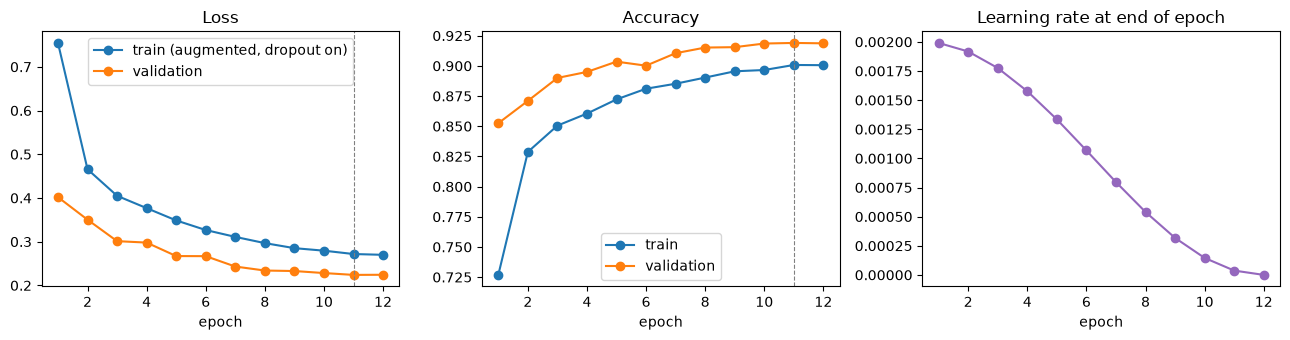

In [61]:
ep = [h["epoch"] for h in history]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
axes[0].plot(ep, [h["train_loss"] for h in history], marker="o", label="train (augmented, dropout on)")
axes[0].plot(ep, [h["val_loss"] for h in history], marker="o", label="validation")
axes[0].set(title="Loss", xlabel="epoch")
axes[1].plot(ep, [h["train_acc"] for h in history], marker="o", label="train")
axes[1].plot(ep, [h["val_acc"] for h in history], marker="o", label="validation")
axes[1].set(title="Accuracy", xlabel="epoch")
axes[2].plot(ep, [h["lr"] for h in history], marker="o", color="tab:purple")
axes[2].set(title="Learning rate at end of epoch", xlabel="epoch")
for ax in axes[:2]:
    ax.axvline(best_epoch, color="gray", ls="--", lw=0.8)
    ax.legend()
plt.tight_layout()
plt.show()

### Step 5 — Reload the best checkpoint into a fresh model and verify it

In [62]:
checkpoint = torch.load(best_path, map_location=DEVICE, weights_only=True)
restored = FashionCNN().to(DEVICE)
restored.load_state_dict(checkpoint["model"])
restored_val_loss, restored_val_acc = evaluate(restored, val_loader, loss_fn, DEVICE)
print(f"checkpoint from epoch {checkpoint['epoch']} ({best_path.stat().st_size / 1e6:.1f} MB): "
      f"saved val loss {checkpoint['val_loss']:.5f} | recomputed after reload {restored_val_loss:.5f}")
assert math.isclose(restored_val_loss, checkpoint["val_loss"], rel_tol=1e-4), "reloaded model does not reproduce the saved validation loss"
print("✅ the reloaded model reproduces the best validation result")

checkpoint from epoch 11 (5.1 MB): saved val loss 0.22405 | recomputed after reload 0.22405
✅ the reloaded model reproduces the best validation result


### Step 6 — Evaluate on the test set (once)

In [63]:
from sklearn.metrics import confusion_matrix

test_loss, test_acc = evaluate(restored, test_loader, loss_fn, DEVICE)
all_preds, all_labels = [], []
restored.eval()
with torch.inference_mode():
    for xb, yb in test_loader:
        all_preds.append(restored(xb.to(DEVICE)).argmax(1).cpu())
        all_labels.append(yb)
all_preds, all_labels = torch.cat(all_preds).numpy(), torch.cat(all_labels).numpy()

cm = confusion_matrix(all_labels, all_preds)
per_class = cm.diagonal() / cm.sum(axis=1)
print(f"TEST accuracy {test_acc:.4f} | test loss {test_loss:.4f} | (validation accuracy was {restored_val_acc:.4f})")
for c in np.argsort(per_class):
    print(f"  {CLASSES[c]:12s} {per_class[c]:.3f}")
off_diag = cm - np.diag(np.diag(cm))
t_c, p_c = np.unravel_index(off_diag.argmax(), cm.shape)
print(f"most common mistake: {CLASSES[t_c]} predicted as {CLASSES[p_c]} ({off_diag.max()} of {cm[t_c].sum()} test images)")
print(f"project runtime: {time.perf_counter() - project_start:.0f} s on {DEVICE}")

TEST accuracy 0.9140 | test loss 0.2355 | (validation accuracy was 0.9190)
  Shirt        0.711
  Coat         0.870
  Pullover     0.875
  T-shirt/top  0.880
  Dress        0.919
  Ankle boot   0.965
  Sneaker      0.971
  Sandal       0.982
  Bag          0.983
  Trouser      0.984
most common mistake: Shirt predicted as T-shirt/top (111 of 1000 test images)
project runtime: 118 s on mps


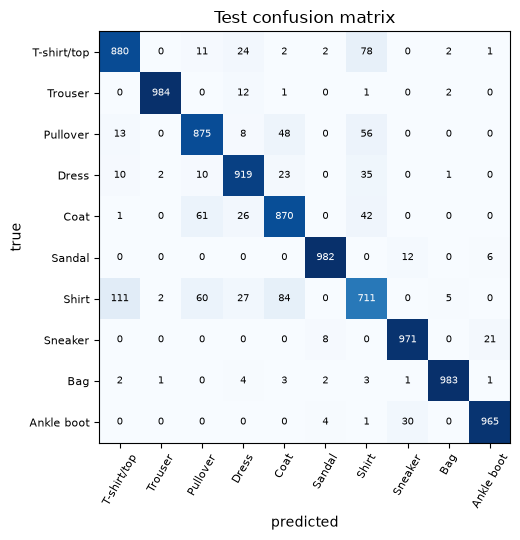

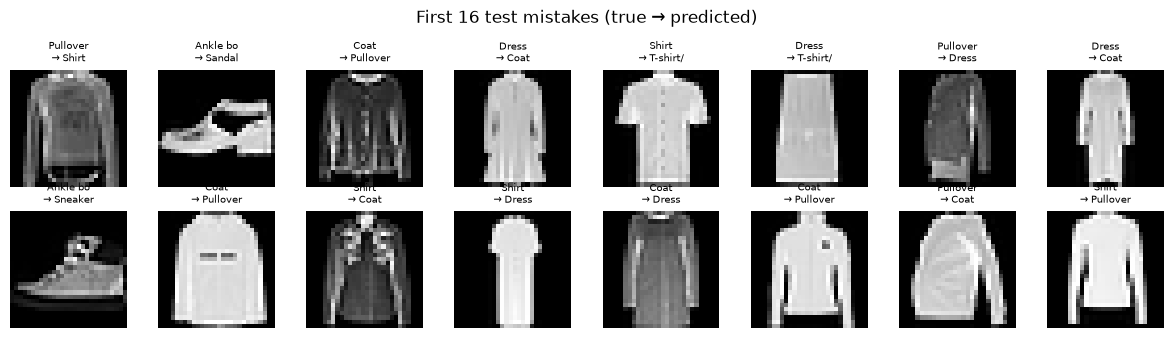

In [64]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.imshow(cm, cmap="Blues")
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=7, color="white" if cm[i, j] > cm.max() / 2 else "black")
ax.set(xticks=range(10), yticks=range(10), xlabel="predicted", ylabel="true", title="Test confusion matrix")
ax.set_xticklabels(CLASSES, rotation=60, fontsize=8)
ax.set_yticklabels(CLASSES, fontsize=8)
plt.tight_layout()
plt.show()

raw_test = datasets.FashionMNIST(DATA_DIR, train=False)            # raw uint8 images for display
wrong_idx = np.flatnonzero(all_preds != all_labels)[:16]
fig, axes = plt.subplots(2, 8, figsize=(12, 3.4))
for ax, idx in zip(axes.ravel(), wrong_idx):
    ax.imshow(raw_test.data[idx], cmap="gray")
    ax.set_title(f"{CLASSES[all_labels[idx]][:8]}\n→ {CLASSES[all_preds[idx]][:8]}", fontsize=7)
    ax.axis("off")
fig.suptitle("First 16 test mistakes (true → predicted)")
plt.tight_layout()
plt.show()

**Stretch goals**
1. Add a third conv block or widen the network; does validation loss improve enough to justify the extra compute?
2. Replace the cosine schedule with `OneCycleLR` and compare at the same number of epochs.
3. Resume training from `fashion_cnn_best.pt` (model + optimizer + scheduler) for 3 more epochs.
4. Run the training step under `torch.autocast` and `torch.compile` on a CUDA GPU (e.g. Colab) and measure the speed-up.
5. Fine-tune a pretrained `torchvision.models.resnet18(weights=ResNet18_Weights.DEFAULT)` (images resized to 3×224×224) and compare accuracy and cost.

### 🗣️ How to talk about this in an interview
- "I trained a two-block CNN with BatchNorm and dropout on FashionMNIST, splitting 54k/6k/10k with a seeded shuffle — normalization statistics came from the training split only and augmentation was applied to training images only."
- "I used AdamW with no weight decay on biases and BatchNorm parameters, a half-epoch warmup into cosine decay stepped per batch, and gradient clipping at norm 1."
- "Early stopping monitored validation loss; I saved a full checkpoint, reloaded it into a fresh model, asserted it reproduced the validation loss, and only then evaluated on the test set once."
- "The confusion matrix shows the errors concentrate on visually similar upper-body garments (shirt vs T-shirt/pullover/coat), which suggests higher resolution features or more capacity rather than more regularization."
- "The training loop computes metrics from the same forward pass and accumulates them as device tensors, so there's no second forward pass and no per-step GPU sync."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. What does "eager execution" mean in PyTorch, and where does `torch.compile` fit in?**

<details><summary>Show answer</summary>

- **30-second answer:** Eager (define-by-run) means each operation executes immediately as Python runs, and autograd records a fresh graph every forward pass — so you can use `print`, debuggers, and ordinary `if`/`for`. `torch.compile` (PyTorch 2.x) optionally captures that Python into a graph with TorchDynamo and generates fused kernels with TorchInductor, trading a one-time compile cost for faster steps.
- **Go deeper:** Compilation specializes on input shapes and falls back to eager ("graph breaks") on code it can't trace; changing shapes can trigger recompiles. For comparison, TensorFlow 2 is also eager by default, and `tf.function` is what traces Python into a graph — graph mode is the opt-in in both frameworks now.
- **❌ Common wrong answer:** "PyTorch builds a static graph before running" or "TensorFlow gets eager execution *through* `tf.function`" — `tf.function` does the opposite: it turns eager code into a graph.

</details>

**Q2. What is the difference between `model.eval()` and `torch.no_grad()` / `torch.inference_mode()`?**

<details><summary>Show answer</summary>

- **30-second answer:** `model.eval()` changes layer *behaviour*: dropout is disabled and BatchNorm uses (and stops updating) its running statistics. `no_grad`/`inference_mode` stop autograd from recording the graph, saving memory and time. They are independent — evaluation needs both.
- **Go deeper:** `inference_mode` is stricter and faster than `no_grad` (tensors created in it can't later be used in autograd). Forgetting `eval()` gives stochastic validation scores and silently shifts BatchNorm's running averages toward the validation data.
- **❌ Common wrong answer:** "`torch.no_grad()` puts the model in evaluation mode."

</details>

**Q3. Why do we call `optimizer.zero_grad()` every step?**

<details><summary>Show answer</summary>

- **30-second answer:** `backward()` **adds** into `.grad` instead of overwriting it, so without clearing, each step would use the sum of all previous gradients — effectively a growing learning rate in stale directions.
- **Go deeper:** Accumulation is a deliberate feature: it enables gradient accumulation over micro-batches and summing gradients from several losses. `zero_grad()` defaults to `set_to_none=True`, which frees the memory and lets optimizers skip parameters without gradients.
- **❌ Common wrong answer:** "It resets the weights" or "it's only needed in the first iteration."

</details>

**Q4. What inputs does `nn.CrossEntropyLoss` expect, and what does it do internally?**

<details><summary>Show answer</summary>

- **30-second answer:** Raw, unnormalized **logits** of shape `(N, C)` and integer class indices of shape `(N,)` (dtype `int64`). Internally it computes `log_softmax` with the log-sum-exp trick and then the negative log-likelihood, averaged over the batch.
- **Go deeper:** Useful options: `weight` for class imbalance, `ignore_index` (e.g. padding tokens in language models), `label_smoothing`, and probability targets of shape `(N, C)`. For sequence models, reshape `(N, T, C)` logits to `(N·T, C)` or move the class dimension to position 1.
- **❌ Common wrong answer:** Adding `nn.Softmax` as the last layer before `CrossEntropyLoss`, or passing one-hot float targets while believing they're indices.

</details>

**Q5. Adam vs AdamW — and why exclude biases and normalization weights from weight decay?**

<details><summary>Show answer</summary>

- **30-second answer:** Adam's `weight_decay` adds `λθ` to the gradient, which then gets divided by Adam's adaptive denominator, so the effective decay is inconsistent across parameters. AdamW **decouples** it — shrinks weights directly by `lr·λ·θ` — which regularizes as intended and is the standard for transformers. Biases and norm gains don't cause overfitting through scale, and decaying them tends to hurt, so they go in a no-decay parameter group.
- **Go deeper:** In this notebook, with a zero loss gradient, Adam(weight_decay=0.01) pushed a weight from 1.0 to ~0.08 in 10 steps, while AdamW moved it to 0.99 — Adam normalizes even the tiny decay gradient into a full-size step. Reference: Loshchilov & Hutter, *Decoupled Weight Decay Regularization*.
- **❌ Common wrong answer:** "L2 regularization and weight decay are identical for every optimizer" — true for plain SGD, not for adaptive methods.

</details>

**Q6. Explain mixed-precision training. When do you need a `GradScaler`?**

<details><summary>Show answer</summary>

- **30-second answer:** `torch.autocast` runs most matrix multiplies and convolutions in a 16-bit dtype while weights, losses, and sensitive ops stay float32 — cutting activation memory and speeding up hardware with fast 16-bit kernels. With **float16**, small gradients underflow to zero, so `GradScaler` multiplies the loss by a large factor before `backward`, unscales before the step, and skips steps with `inf`/`nan`. **bfloat16** has float32's range, so no scaler is needed.
- **Go deeper:** Speed-ups depend on hardware: large on NVIDIA GPUs with tensor cores, and possibly none for small models elsewhere (this notebook measured it on MPS). Call `scaler.unscale_(optimizer)` before gradient clipping so the clip threshold applies to true gradient values.
- **❌ Common wrong answer:** "Mixed precision converts the model's weights to float16" — autocast keeps float32 master weights.

</details>

**Q7. What's the difference between `view`, `reshape`, and `contiguous()`?**

<details><summary>Show answer</summary>

- **30-second answer:** `view` returns a tensor sharing the same memory with a new shape, and requires compatible strides (contiguous memory). `reshape` returns a view when possible and otherwise copies. `contiguous()` copies a tensor into a fresh, contiguous block when needed — e.g. after `transpose`/`permute`.
- **Go deeper:** A tensor is storage + shape + **strides** (how many elements to skip per dimension). `permute` only changes strides, which is why it's O(1) but breaks `view`. In attention code you'll see `x.transpose(1, 2).contiguous().view(B, T, C)`.
- **❌ Common wrong answer:** "`view` and `reshape` are identical" or "`reshape` always copies."

</details>

### 💻 Coding

**Q8. Write a training loop and an evaluation loop from memory. What details matter?**

<details><summary>Show answer</summary>

- **30-second answer:** `model.train()`; for each batch: move to device → `logits = model(x)` → `loss = loss_fn(logits, y)` → `optimizer.zero_grad()` → `loss.backward()` → (clip) → `optimizer.step()` → (per-step `scheduler.step()`); accumulate metrics from the **same** `logits`. For evaluation: `model.eval()` and `torch.inference_mode()`, no optimizer calls.
- **Go deeper:** Accumulate running loss with `loss.detach()` or `loss.item()` (not `loss`, which keeps the graph); avoid per-step `.item()` on GPUs to prevent sync stalls; shuffle only the training loader; early-stop on validation, test once.
- **❌ Common wrong answer:** Calling `optimizer.step()` before `backward()`, or running a second forward pass after the step to compute accuracy (different weights, and BatchNorm statistics get updated twice).

</details>

**Q9. How do you implement a custom layer with its own backward pass?**

<details><summary>Show answer</summary>

- **30-second answer:** Subclass `torch.autograd.Function` with static `forward(ctx, *inputs)` and `backward(ctx, grad_output)`; save what backward needs with `ctx.save_for_backward`, return one gradient per forward input (or `None`), and call it via `MyFn.apply(x)` inside an `nn.Module`.
- **Go deeper:** Most custom layers only need an `nn.Module` with a `forward` — autograd derives the backward. Write a custom `Function` for memory savings, numerical stability, or fused kernels, and verify it with `torch.autograd.gradcheck` in float64.
- **❌ Common wrong answer:** Overriding `backward` on an `nn.Module`, or returning gradients with shapes that don't match the inputs.

</details>

**Q10. What should a checkpoint contain so training can resume exactly, and how do you load it safely?**

<details><summary>Show answer</summary>

- **30-second answer:** The model `state_dict`, optimizer state (e.g. Adam's moment buffers), scheduler state, epoch/step, the best validation metric, and RNG/generator states. Load with `torch.load(path, map_location=device, weights_only=True)` and `load_state_dict`.
- **Go deeper:** `weights_only=True` (the default since PyTorch 2.6) refuses to unpickle arbitrary objects, protecting against malicious files; `map_location` lets a GPU-trained checkpoint load on CPU. Save `state_dict`s rather than whole pickled models so refactored code can still load them. Formats like safetensors are common for sharing weights.
- **❌ Common wrong answer:** "Save only the model weights" — resuming then restarts Adam's statistics and the schedule, producing a loss spike and a different run.

</details>

### 🐛 Debugging Scenarios

**Q11. Your loss doesn't decrease at all. Walk through your debugging process.**

<details><summary>Show answer</summary>

- **30-second answer:** Check the initial loss (≈ ln C for C classes), then try to **overfit a single small batch**. If that fails the bug is in code: `zero_grad`/`step` order, parameters not passed to the optimizer, detached tensors, wrong loss inputs (softmax before cross-entropy, label dtype), or a learning rate that's far off. Inspect per-layer gradient norms to see where the signal stops.
- **Go deeper:** If single-batch overfitting works, suspect data (labels misaligned with inputs, broken augmentation, missing normalization) or too much regularization. Visualize a batch *after* the transforms. Karpathy's "A Recipe for Training Neural Networks" is the classic checklist.
- **❌ Common wrong answer:** "Increase model size and train longer."

</details>

**Q12. Training crashes with a GPU out-of-memory error. What can you do?**

<details><summary>Show answer</summary>

- **30-second answer:** Reduce the batch size and use **gradient accumulation** to keep the effective batch; enable mixed precision; use `torch.inference_mode()` for evaluation; make sure you aren't accumulating `loss` tensors (kept graphs) or storing GPU tensors in Python lists; use activation checkpointing for very deep models.
- **Go deeper:** Memory = parameters + gradients + optimizer state (Adam: 2 extra copies) + activations (grow with batch × sequence length/resolution). For large models: FSDP/ZeRO sharding, 8-bit optimizers, LoRA. `torch.cuda.memory_summary()` shows where memory goes; `empty_cache()` only returns cached blocks, it doesn't fix a leak.
- **❌ Common wrong answer:** "Call `torch.cuda.empty_cache()` every step."

</details>

**Q13. Validation accuracy is 100% from the first epoch — or much worse than expected. What do you suspect?**

<details><summary>Show answer</summary>

- **30-second answer:** A too-good score usually means **leakage** or a broken split: duplicates across splits, a feature that encodes the label, or a validation set cut from class-sorted data so it contains one class. A too-bad score often means missing `model.eval()`, different preprocessing for validation (e.g. no normalization), or labels shuffled independently of inputs.
- **Go deeper:** Always print class counts per split, use stratified/grouped splits (by patient, user, or time where relevant), compute normalization statistics on train only, and look at a few validation examples with their predictions.
- **❌ Common wrong answer:** "The model is just very good" — without checking the split.

</details>

### 🏗️ Design

**Q14. GPU utilization hovers around 30% during training. How do you find and fix the bottleneck?**

<details><summary>Show answer</summary>

- **30-second answer:** The GPU is waiting for data or for Python. Time the data loader alone versus the training step. Fixes: more `num_workers`, `pin_memory=True` with `non_blocking=True` copies (CUDA), `persistent_workers=True`, pre-decoding or caching data, moving augmentation to the GPU, larger batches, avoiding per-step `.item()`/`.cpu()` syncs, and `torch.compile` to cut Python overhead.
- **Go deeper:** Use `torch.profiler` to see CPU vs GPU time per operation. Workers aren't free: for tiny in-memory data they can be slower (measured in Section 6), and on macOS/Windows spawned workers must import your dataset code from a module.
- **❌ Common wrong answer:** "Buy a bigger GPU."

</details>

## 🧪 Quick Quiz

Predict the answer, then reveal.

**1.** `torch.arange(6).view(2, 3).T.is_contiguous()`
<details><summary>Answer</summary>

`False` — transposing swaps the strides without moving data, so the tensor is no longer laid out row by row in memory. `.view(6)` on it would fail; `.reshape(6)` copies.
</details>

**2.** `x = torch.tensor(2.0, requires_grad=True)`, then `(x * x).backward()` twice (building the expression again each time). What is `x.grad`?
<details><summary>Answer</summary>

`tensor(8.)` — each backward adds `2x = 4`, and gradients accumulate.
</details>

**3.** How many parameters does `nn.Linear(10, 5)` have?
<details><summary>Answer</summary>

`55` — a 5×10 weight matrix plus 5 biases.
</details>

**4.** What shape comes out of `nn.MaxPool2d(2)(nn.Conv2d(1, 16, 3, padding=1)(torch.zeros(8, 1, 28, 28)))`?
<details><summary>Answer</summary>

`torch.Size([8, 16, 14, 14])` — padding 1 keeps 28×28 with 16 channels, pooling halves height and width.
</details>

**5.** What is the dtype of `torch.tensor([1, 2, 3]) / 2`?
<details><summary>Answer</summary>

`torch.float32` — `/` is true division, so integers are promoted to the default float type. Use `//` for integer (floor) division.
</details>

## 📚 Resources

### 📖 Official Docs
- [Learn the Basics — PyTorch Tutorials](https://docs.pytorch.org/tutorials/beginner/basics/intro.html) — the official step-by-step path through tensors, data, models, and training
- [torch.optim](https://docs.pytorch.org/docs/2.14/optim.html) — optimizers, parameter groups, and learning-rate schedulers
- [torch.utils.data](https://docs.pytorch.org/docs/2.14/data.html) — `Dataset`, `DataLoader`, workers, samplers, and memory pinning
- [Automatic Mixed Precision package - torch.amp](https://docs.pytorch.org/docs/2.14/amp.html) — autocast op lists and `GradScaler`
- [MPS backend](https://docs.pytorch.org/docs/2.14/notes/mps.html) — using Apple Silicon GPUs
- [Reproducibility](https://docs.pytorch.org/docs/2.14/notes/randomness.html) — seeds, deterministic algorithms, and DataLoader workers
- [Introduction to torch.compile](https://docs.pytorch.org/tutorials/intermediate/torch_compile_tutorial.html)
- [Saving and Loading Models](https://docs.pytorch.org/tutorials/beginner/saving_loading_models.html) — `state_dict`s and checkpoints
- [Transforming images, videos, boxes and more — torchvision](https://docs.pytorch.org/vision/stable/transforms.html) — the `transforms.v2` API used here

### 🎥 Videos
- [Patrick Loeber — Deep Learning With PyTorch - Full Course](https://www.youtube.com/watch?v=c36lUUr864M) (4 h 35 min) — a clear, code-along tour of tensors, autograd, datasets, CNNs, and transfer learning; good second pass over this notebook
- [Daniel Bourke — Learn PyTorch for deep learning in a day. Literally.](https://www.youtube.com/watch?v=Z_ikDlimN6A) (25 h 36 min) — very beginner-friendly and exhaustive; dip into the chapters on workflows and computer vision
- [Andrej Karpathy — Let's reproduce GPT-2 (124M)](https://www.youtube.com/watch?v=l8pRSuU81PU) (4 h 1 min) — a real training run using mixed precision, `torch.compile`, gradient accumulation, and warmup + cosine schedules

### 📄 Papers
- [Paszke et al. (2019) — PyTorch: An Imperative Style, High-Performance Deep Learning Library](https://arxiv.org/abs/1912.01703)
- [Loshchilov & Hutter (2017) — Decoupled Weight Decay Regularization](https://arxiv.org/abs/1711.05101) — AdamW
- [Loshchilov & Hutter (2016) — SGDR: Stochastic Gradient Descent with Warm Restarts](https://arxiv.org/abs/1608.03983) — cosine schedules
- [Ioffe & Szegedy (2015) — Batch Normalization](https://arxiv.org/abs/1502.03167)
- [Micikevicius et al. (2017) — Mixed Precision Training](https://arxiv.org/abs/1710.03740) — loss scaling
- [Goyal et al. (2017) — Accurate, Large Minibatch SGD: Training ImageNet in 1 Hour](https://arxiv.org/abs/1706.02677) — warmup and the linear scaling rule
- [Xiao et al. (2017) — Fashion-MNIST: a Novel Image Dataset for Benchmarking Machine Learning Algorithms](https://arxiv.org/abs/1708.07747)

### 📘 Books & Courses
- [Zero to Mastery Learn PyTorch for Deep Learning (free online book)](https://www.learnpytorch.io/) — Daniel Bourke's companion book to the video
- [Dive into Deep Learning (free online book)](https://d2l.ai/) — PyTorch implementations of every chapter
- [A Recipe for Training Neural Networks](https://karpathy.github.io/2019/04/25/recipe/) — Karpathy's debugging-first training checklist
- [PyTorch internals : ezyang's blog](http://blog.ezyang.com/2019/05/pytorch-internals/) — strides, storage, and dispatch explained by a core developer

### 🏋️ Practice
- [srush/Tensor-Puzzles (GitHub)](https://github.com/srush/Tensor-Puzzles) — rebuild NumPy/PyTorch functions using only broadcasting; great for shape fluency
- [Deep-ML | Practice Machine Learning](https://www.deep-ml.com/) — coding problems on layers, losses, and optimizers

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API |
|---|---|---|
| Tensors | arrays on CPU/GPU | `torch.tensor`, `from_numpy` (shares), `.to(device)`, `.float()`, `.cpu().numpy()` |
| Shapes | reshape without copying | `view` (contiguous), `reshape`, `permute`, `unsqueeze`, `cat`/`stack` |
| Autograd | gradients automatically | `requires_grad=True`, `loss.backward()`, `.grad`, `no_grad`, `inference_mode`, `detach` |
| Modules | layers & models | subclass `nn.Module`, `nn.ModuleList`, `parameters()`, `state_dict()` |
| Losses | what to minimize | `CrossEntropyLoss(logits, int labels)`, `BCEWithLogitsLoss`, `MSELoss` |
| Optimizers | update rule | `AdamW(param_groups, lr, weight_decay)`, `zero_grad` → `backward` → `step` |
| Data | batches | `Dataset(__len__, __getitem__)`, `DataLoader(batch_size, shuffle, num_workers, generator)` |
| Train/eval | layer behaviour | `model.train()` / `model.eval()` + `torch.inference_mode()` |
| CNN | image features | `Conv2d` out = ⌊(H + 2p − k)/s⌋ + 1, `MaxPool2d`, `BatchNorm2d` |
| Regularization | generalize | `Dropout`, AdamW decay (not on biases/norms), `transforms.v2` augmentation (train only) |
| Schedules | vary the lr | `LambdaLR`, `LinearLR` → `CosineAnnealingLR` via `SequentialLR`; step after `optimizer.step()` |
| Mixed precision | 16-bit compute | `torch.autocast(device_type, dtype)`, `torch.amp.GradScaler` for float16 |
| Compile | faster steps | `torch.compile(model)` — first call compiles |
| Checkpoints | save/resume | `torch.save({model, optimizer, scheduler, epoch})`, `torch.load(..., weights_only=True)` |
| Debugging | find bugs fast | loss ≈ ln C, overfit one batch, shape asserts, grad norms, `torch.isfinite`, `detect_anomaly` |

## ➡️ What's Next

**[03 · Transformers From Scratch](03_Transformers_From_Scratch.ipynb)** — with tensors, autograd, and a reliable training loop in hand, you'll build attention, positional encodings, and a mini-GPT in PyTorch — the architecture behind every modern LLM.